# Financial Tweet Sentiment Classification — Tested Techniques

**Task:** classify the market sentiment of finance tweets as **Bearish (0) / Bullish (1) / Neutral (2)**.

This notebook documents every technique we experimented with, mapped to the project rubric:

1. Data Exploration · 2. Corpus Split · 3. Preprocessing · 4. Feature Engineering (BoW / word2vec / Transformer) · 5. Classification (classical ML + Transformer encoders + decoder LLM) · 6. Evaluation & Analysis.

It is **self-contained**: all project code is inlined in the Setup section below, so the notebook needs no external modules.

## Table of Contents

- [Setup](#setup)
  - [Imports](#imports)
  - [Configs](#configs)
  - [Utils functions](#utils-functions)
  - [Evaluate functions](#evaluate-functions)
  - [Preprocessing functions](#preprocessing-functions)
  - [EDA functions](#eda-functions)
  - [Word embedding functions](#word-embedding-functions)
    - [Sentence embedding functions - Transformer & decoder](#sentence-embedding-functions---transformer-decoder)
    - [1. Transformer trainer functions](#1-transformer-trainer-functions)
    - [2. Decoder (Qwen) functions](#2-decoder-qwen-functions)
- [1. Data Exploration](#1-data-exploration)
  - [1.1 Visual analysis](#11-visual-analysis)
  - [1.2 Word clouds per sentiment class](#12-word-clouds-per-sentiment-class)
  - [1.3 Conclusions](#13-conclusions)
- [2. Corpus Split](#2-corpus-split)
- [3. Data Preprocessing](#3-data-preprocessing)
- [4. Feature Engineering](#4-feature-engineering)
  - [4.1 Bag-of-Words family (BoW + TF-IDF)](#41-bag-of-words-family-bow-tf-idf)
  - [4.2 word2vec family](#42-word2vec-family)
  - [4.3 Transformer Encoder features](#43-transformer-encoder-features)
- [5. Classification Models](#5-classification-models)
  - [5.1 Traditional ML (≥2 variations each, ≥2 algorithms)](#51-traditional-ml-2-variations-each-2-algorithms)
  - [5.1b Class-Imbalance Strategies](#51b-class-imbalance-strategies)
  - [5.2 Transformer Encoders — fine-tuning (≥2 variations)](#52-transformer-encoders-fine-tuning-2-variations)
  - [5.3 Extra Transformer Encoders (Extra Work)](#53-extra-transformer-encoders-extra-work)
  - [5.4 Decoder model for classification](#54-decoder-model-for-classification)
- [6. Evaluation and Analysis](#6-evaluation-and-analysis)


## Setup

In [1]:
import os, sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))
print(f"Working directory: {os.getcwd()}")



Working directory: C:\Users\pedro\Documentos\NOVA IMS\2º semestre- eu\Text mining\TextMining-Corpora


In [2]:
# %pip install -q -r requirements.txt  # deps already installed in this kernel

In [3]:
import warnings
warnings.filterwarnings("ignore")

# Third-party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from IPython.display import Image, display

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, classification_report,
)
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier




## 0. Project Modules (Self-Contained)

To comply with the project guidelines requiring a strictly self-contained notebook, all modularized functions (which were designed to reside in a `src/` package) are instantiated in this initial section. 
They are ordered by dependency so the kernel resolves them sequentially.

### Module: `config.py`

In [4]:
import re

# Reproducibility
SEED = 42

# Dataset splits
VAL_SIZE = 0.20
K_FOLD_N_SPLITS = 5

# Paths
TRAIN_CSV_PATH = "data/train.csv"
TEST_CSV_PATH = "data/test.csv"
RESULTS_CSV_PATH = "outputs/results.csv"
OUTPUT_PRED_PATH = "outputs/pred_best.csv"

# Error analysis output paths
CONF_MATRIX_PLOT_PATH = "outputs/confusion_matrix.png"
MISCLASSIFIED_TXT_PATH = "outputs/misclassified_report.txt"
MISCLASSIFIED_JSON_PATH = "outputs/misclassified_analysis.json"

# Labels
NUM_LABELS = 3
LABEL_NAMES = {0: "Bearish", 1: "Bullish", 2: "Neutral"}
LABEL2ID = {"Bearish": 0, "Bullish": 1, "Neutral": 2}
ID2LABEL = {0: "Bearish", 1: "Bullish", 2: "Neutral"}

# DistilBERT
DISTILBERT_MODEL_NAME = "distilbert-base-uncased"
DISTILBERT_N_SAMPLES_SPIKE = 200
DISTILBERT_CACHE_DIR = "outputs/distilbert_cache"
DISTILBERT_CHECKPOINT_DIR = "outputs/distilbert_checkpoints"

# Qwen decoder
QWEN_MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

# Twitter-RoBERTa
ROBERTA_MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment"
ROBERTA_N_SAMPLES_SPIKE = 200
ROBERTA_CACHE_DIR = "outputs/roberta_cache"
ROBERTA_CHECKPOINT_DIR = "outputs/roberta_checkpoints"

# FinBERT
FINBERT_MODEL_NAME = "ProsusAI/finbert"
FINBERT_N_SAMPLES_SPIKE = 200
FINBERT_CACHE_DIR = "outputs/finbert_cache"
FINBERT_CHECKPOINT_DIR = "outputs/finbert_checkpoints"

# DeBERTa-v3
DEBERTA_MODEL_NAME = "microsoft/deberta-v3-base"
DEBERTA_N_SAMPLES_SPIKE = 200
DEBERTA_CACHE_DIR = "outputs/deberta_cache"
DEBERTA_CHECKPOINT_DIR = "outputs/deberta_checkpoints"

# Feature matrix cache paths
BOW_TRAIN_PATH       = "outputs/X_train_bow.npz"
BOW_VAL_PATH         = "outputs/X_val_bow.npz"
TFIDF_UNI_TRAIN_PATH = "outputs/X_train_tfidf_uni.npz"
TFIDF_UNI_VAL_PATH   = "outputs/X_val_tfidf_uni.npz"
TFIDF_OPT_TRAIN_PATH = "outputs/X_train_tfidf_opt.npz"
TFIDF_OPT_VAL_PATH   = "outputs/X_val_tfidf_opt.npz"

# Leaderboard CSV schema
RESULTS_HEADERS = [
    "timestamp", "owner", "model_name", "feature_description",
    "accuracy", "precision_macro", "recall_macro", "f1_macro",
    "parameters", "f1_per_class", "notes",
]

# Preprocessing — placeholders
URL_PLACEHOLDER = "URL_PLACEHOLDER"
MENTION_PLACEHOLDER = "MENTION_PLACEHOLDER"
CASHTAG_PLACEHOLDER = "CASHTAG_PLACEHOLDER"
PROTECTED_PLACEHOLDERS = {URL_PLACEHOLDER, MENTION_PLACEHOLDER, CASHTAG_PLACEHOLDER}

# Preprocessing — financial noise tokens (used on top of NLTK stopwords)
FINANCIAL_STOPWORDS = {
    "rt", "amp", "co", "qt", "http", "https", "via",
    "stock", "stocks", "ticker", "tickers", "share", "shares",
}

# EDA — display
LABEL_PALETTE = {
    "Bearish": "#E06666",
    "Bullish": "#6AA84F",
    "Neutral": "#4A90E2",
}

# EDA — artifact detection patterns
URL_PATTERN     = re.compile(r'https?://\S+|www\.\S+')
MENTION_PATTERN = re.compile(r'@\w+')
CASHTAG_PATTERN = re.compile(r'\$\w+')
HASHTAG_PATTERN = re.compile(r'#\w+')

# EDA — fast stopword set (no NLTK dependency)
DEFAULT_STOPWORDS = {
    "i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you", "your", "yours",
    "yourself", "yourselves", "he", "him", "his", "himself", "she", "her", "hers", "herself",
    "it", "its", "itself", "they", "them", "their", "theirs", "themselves", "what", "which",
    "who", "whom", "this", "that", "these", "those", "am", "is", "are", "was", "were", "be",
    "been", "being", "have", "has", "had", "having", "do", "does", "did", "doing", "a", "an",
    "the", "and", "but", "if", "or", "because", "as", "until", "while", "of", "at", "by",
    "for", "with", "about", "against", "between", "into", "through", "during", "before",
    "after", "above", "below", "to", "from", "up", "down", "in", "out", "on", "off", "over",
    "under", "again", "further", "then", "once", "here", "there", "when", "where", "why",
    "how", "all", "any", "both", "each", "few", "more", "most", "other", "some", "such",
    "no", "nor", "not", "only", "own", "same", "so", "than", "too", "very", "s", "t", "can",
    "will", "just", "don", "should", "now", "d", "ll", "m", "o", "re", "ve", "y",
    *FINANCIAL_STOPWORDS,
}



### Module: `utils.py`

In [5]:
def log_info(msg: str) -> None:
    print(f"[INFO] {msg}")

def log_success(msg: str) -> None:
    print(f"[SUCCESS] {msg}")

def log_error(msg: str) -> None:
    print(f"[ERROR] {msg}")

def log_warning(msg: str) -> None:
    print(f"[WARNING] {msg}")

def print_header(title: str, width: int = 60) -> None:
    print("=" * width)
    print(title)
    print("=" * width)

def print_separator(width: int = 60) -> None:
    print("-" * width)



### Module: `evaluate.py`

In [6]:
import os
import csv
from datetime import datetime

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    classification_report,
    confusion_matrix,
)





def compute_metrics(y_true, y_pred) -> dict:
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    per_class = f1_score(y_true, y_pred, average=None, zero_division=0)
    f1_per_class = {
        name: float(per_class[i]) if i < len(per_class) else 0.0
        for i, name in LABEL_NAMES.items()
    }
    return {
        "accuracy": float(accuracy),
        "precision_macro": float(precision),
        "recall_macro": float(recall),
        "f1_macro": float(f1),
        "f1_per_class": f1_per_class,
    }


def log_model_run(
    model_name: str,
    feature_desc: str,
    metrics: dict,
    params: str = "",
    owner: str = "",
    notes: str = "",
) -> None:
    """Logs a model run to results.csv idempotently — updates if the same key exists."""
    os.makedirs(os.path.dirname(RESULTS_CSV_PATH), exist_ok=True)

    new_row = {
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "owner": owner,
        "model_name": model_name,
        "feature_description": feature_desc,
        "accuracy": f"{metrics['accuracy']:.4f}",
        "precision_macro": f"{metrics['precision_macro']:.4f}",
        "recall_macro": f"{metrics['recall_macro']:.4f}",
        "f1_macro": f"{metrics['f1_macro']:.4f}",
        "parameters": params,
        "f1_per_class": str(metrics.get("f1_per_class", "")),
        "notes": notes,
    }

    def _is_match(row: dict) -> bool:
        return (
            row["model_name"] == model_name
            and row["feature_description"] == feature_desc
            and row["parameters"] == params
            and row["owner"] == owner
        )

    existing_rows = []
    updated = False

    if os.path.exists(RESULTS_CSV_PATH) and os.path.getsize(RESULTS_CSV_PATH) > 0:
        try:
            with open(RESULTS_CSV_PATH, mode="r", newline="", encoding="utf-8") as f:
                reader = csv.reader(f)
                next(reader, None)
                for r in reader:
                    if len(r) != len(RESULTS_HEADERS):
                        continue
                    row = dict(zip(RESULTS_HEADERS, r))
                    if _is_match(row):
                        existing_rows.append(new_row)
                        updated = True
                    else:
                        existing_rows.append(row)
        except Exception as e:
            log_warning(f"Error reading leaderboard CSV: {e}. Resetting.")
            existing_rows = []

    if not updated:
        existing_rows.append(new_row)

    with open(RESULTS_CSV_PATH, mode="w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=RESULTS_HEADERS)
        writer.writeheader()
        writer.writerows(existing_rows)

    log_info(f"{'Updated' if updated else 'Added'} run in {RESULTS_CSV_PATH}")


def evaluate_and_log(
    y_true, y_pred,
    model_name: str,
    feature_desc: str,
    params: str = "",
    owner: str = "",
) -> dict:
    """Evaluates predictions, prints report, and logs to results.csv."""
    metrics = compute_metrics(y_true, y_pred)

    print_header(f"MODEL EVALUATION: {model_name} ({feature_desc})")
    log_info(f"Accuracy          : {metrics['accuracy']:.4f}")
    log_info(f"Precision (Macro) : {metrics['precision_macro']:.4f}")
    log_info(f"Recall (Macro)    : {metrics['recall_macro']:.4f}")
    log_info(f"F1 (Macro)        : {metrics['f1_macro']:.4f}")
    print_separator()
    print(classification_report(y_true, y_pred, target_names=list(LABEL_NAMES.values()), zero_division=0))
    print_separator()
    print(confusion_matrix(y_true, y_pred))

    log_model_run(model_name, feature_desc, metrics, params, owner=owner)
    return metrics


def evaluate_model(y_true, y_pred, owner: str, model, notes: str = "") -> dict:
    """Bento's interface — computes metrics, prints report, and logs to results.csv."""
    model_name = model.__class__.__name__ if hasattr(model, "__class__") else str(model)
    hyperparameters = str(model.get_params()) if hasattr(model, "get_params") else ""

    metrics = compute_metrics(y_true, y_pred)
    print(classification_report(y_true, y_pred, zero_division=0))
    print(confusion_matrix(y_true, y_pred))

    log_model_run(
        model_name=model_name,
        feature_desc="N/A",
        metrics=metrics,
        params=hyperparameters,
        owner=owner,
        notes=notes,
    )

    return {
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "owner": owner,
        "model": model_name,
        "hyperparams": hyperparameters,
        "val_accuracy": metrics["accuracy"],
        "val_p_macro": metrics["precision_macro"],
        "val_r_macro": metrics["recall_macro"],
        "val_f1_macro": metrics["f1_macro"],
        "val_f1_per_class": metrics["f1_per_class"],
        "notes": notes,
    }


def save_submission(
    test_df: pd.DataFrame,
    predictions,
    output_path: str = OUTPUT_PRED_PATH,
    id_col: str = "id",
) -> pd.DataFrame:
    """Saves id + label predictions to CSV."""
    submission = pd.DataFrame({"id": test_df[id_col], "label": predictions})
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    submission.to_csv(output_path, index=False)
    log_success(f"Predictions saved to {output_path} ({len(submission)} rows)")
    return submission



### Module: `preprocessing.py`

In [7]:
import re
import sys
import json
import argparse
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import TweetTokenizer
from nltk.stem import PorterStemmer, WordNetLemmatizer
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold





def _download_nltk_resources() -> None:
    resources = {
        'stopwords': 'corpora/stopwords',
        'punkt': 'tokenizers/punkt',
        'wordnet': 'corpora/wordnet',
        'omw-1.4': 'corpora/omw-1.4',
    }
    for name, path in resources.items():
        try:
            nltk.data.find(path)
        except LookupError:
            nltk.download(name, quiet=True)


_download_nltk_resources()

_SPACE_RE = re.compile(r'\s+')
_UNICODE_MAP = [
    (re.compile(r'[\u201c\u201d\u201e\u201f]'), '"'),
    (re.compile(r'[\u2018\u2019\u201a\u201b]'), "'"),
    (re.compile(r'[\u2012\u2013\u2014\u2015\u2212]'), '-'),
    (re.compile(r'\u2026'), '...'),
    (re.compile(r'\uFFFD'), ' '),
]
_TOKENIZER = TweetTokenizer(preserve_case=True, reduce_len=True, strip_handles=False)

# ── Text preprocessing ────────────────────────────────────────────────────────

def normalize_unicode_punctuation(text: str) -> str:
    if not isinstance(text, str):
        return ""
    for pattern, replacement in _UNICODE_MAP:
        text = pattern.sub(replacement, text)
    return text


def clean_regex(
    text: str,
    url_mode: str = 'replace',
    mention_mode: str = 'replace',
    cashtag_mode: str = 'keep',
) -> str:
    if url_mode == 'remove':
        text = URL_PATTERN.sub('', text)
    elif url_mode == 'replace':
        text = URL_PATTERN.sub(URL_PLACEHOLDER, text)

    if mention_mode == 'remove':
        text = MENTION_PATTERN.sub('', text)
    elif mention_mode == 'replace':
        text = MENTION_PATTERN.sub(MENTION_PLACEHOLDER, text)

    if cashtag_mode == 'remove':
        text = CASHTAG_PATTERN.sub('', text)
    elif cashtag_mode == 'replace':
        text = CASHTAG_PATTERN.sub(CASHTAG_PLACEHOLDER, text)

    return _SPACE_RE.sub(' ', text).strip()


def tokenize_tweet(text: str) -> list:
    return _TOKENIZER.tokenize(text)


def remove_stopwords_from_tokens(tokens: list, extra_stopwords: list = None) -> list:
    all_stops = set(stopwords.words('english')) | FINANCIAL_STOPWORDS
    if extra_stopwords:
        all_stops.update(extra_stopwords)
    return [t for t in tokens if (t.lower() not in all_stops) or (t in PROTECTED_PLACEHOLDERS)]


def apply_stemming(tokens: list) -> list:
    stemmer = PorterStemmer()
    return [t if t in PROTECTED_PLACEHOLDERS else stemmer.stem(t) for t in tokens]


def apply_lemmatization(tokens: list) -> list:
    lemmatizer = WordNetLemmatizer()
    return [t if t in PROTECTED_PLACEHOLDERS else lemmatizer.lemmatize(t) for t in tokens]


def preprocess_tweet(
    text: str,
    lowercase: bool = True,
    url_mode: str = 'replace',
    mention_mode: str = 'replace',
    cashtag_mode: str = 'keep',
    remove_stopwords: bool = True,
    custom_stopwords: list = None,
    use_stemming: bool = False,
    use_lemmatization: bool = True,
    return_str: bool = False,
):
    """Full tweet preprocessing pipeline. Returns token list or joined string."""
    text = normalize_unicode_punctuation(text)
    if lowercase:
        text = text.lower()
    text = clean_regex(text, url_mode=url_mode, mention_mode=mention_mode, cashtag_mode=cashtag_mode)
    tokens = tokenize_tweet(text)
    if remove_stopwords:
        tokens = remove_stopwords_from_tokens(tokens, extra_stopwords=custom_stopwords)
    if use_stemming:
        tokens = apply_stemming(tokens)
    if use_lemmatization:
        tokens = apply_lemmatization(tokens)
    return " ".join(tokens) if return_str else tokens


# ── Train / val splitting (absorbed from train_val_split.py) ──────────────────

def stratified_split(
    dataset: pd.DataFrame,
    test_size: float = VAL_SIZE,
    seed: int = SEED,
) -> tuple[pd.Series, pd.Series, pd.Series, pd.Series]:
    X, y = dataset['text'], dataset['label']
    return train_test_split(X, y, test_size=test_size, random_state=seed, stratify=y)


def create_stratified_kfold(n_splits: int = K_FOLD_N_SPLITS, seed: int = SEED) -> StratifiedKFold:
    return StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)


# ── Smoke tests ───────────────────────────────────────────────────────────────

def run_smoke_tests() -> None:
    """Verifies each preprocessing step with representative tweets."""
    print_header("PREPROCESSING SMOKE TESTS")

    test_tweets = [
        "Downgrades 4/7: $MLND to underperform at Needham—see details... https://t.co/example",
        "Shorting $AAPL here at $180. @elonmusk thoughts? #market #trading",
        "RT @NovaIMS: $BTC is falling down rapidly... RT to warn others!",
        "Having a cup of coffee and watching the market open. Very neutral.",
    ]

    for idx, raw in enumerate(test_tweets, 1):
        log_info(f"Test {idx}: '{raw}'")
        lem = preprocess_tweet(raw, return_str=True)
        log_info(f"  Lemmatized : '{lem}'")
        stem = preprocess_tweet(raw, url_mode='remove', mention_mode='remove',
                                cashtag_mode='replace', use_stemming=True,
                                use_lemmatization=False, return_str=False)
        log_info(f"  Stemmed    : {stem}")

    log_success("Smoke tests complete.")


# ── Main Entry Point for CLI & Agents ─────────────────────────────────────────



### Module: `eda.py`

In [8]:
import os
import re
from collections import Counter
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud



# --- Core Analyzer Class ---

class DatasetAnalyzer:
    def __init__(self, file_path: str, name: str = "Dataset"):
        self.file_path = file_path
        self.name = name
        self.df = None
        self.has_label = False
        self.load_data()

    def load_data(self):
        """Loads dataset from CSV and determines if labels exist."""
        if not os.path.exists(self.file_path):
            raise FileNotFoundError(f"Dataset not found at: {self.file_path}")
        self.df = pd.read_csv(self.file_path)
        self.has_label = "label" in self.df.columns
        # Basic text cleaning to ensure str type
        self.df["text"] = self.df["text"].fillna("").astype(str)

    def analyze_basic_stats(self) -> dict:
        """Returns standard metrics on size, duplicates, and missing rows."""
        total_rows = len(self.df)
        exact_dups = self.df["text"].duplicated().sum()
        ci_dups = self.df["text"].str.lower().str.strip().duplicated().sum()
        empty_rows = (self.df["text"].str.strip() == "").sum()
        
        return {
            "total_rows": total_rows,
            "exact_duplicates": int(exact_dups),
            "trimmed_case_insensitive_duplicates": int(ci_dups),
            "empty_rows": int(empty_rows)
        }

    def analyze_class_distribution(self) -> list:
        """Returns class distribution metrics (counts, percentages) if labels are present."""
        if not self.has_label:
            return []
        
        counts = self.df["label"].value_counts().sort_index()
        total = counts.sum()
        dist = []
        for val, cnt in counts.items():
            dist.append({
                "label_id": int(val),
                "label_name": LABEL_NAMES.get(val, f"Unknown ({val})"),
                "count": int(cnt),
                "percentage": float((cnt / total * 100))
            })
        return dist

    def analyze_text_lengths(self) -> dict:
        """Computes text character length and token count statistics."""
        char_lens = self.df["text"].str.len()
        token_lens = self.df["text"].str.split().str.len()
        
        stats = {
            "char_len": {
                "mean": float(char_lens.mean()),
                "median": float(char_lens.median()),
                "std": float(char_lens.std()),
                "min": int(char_lens.min()),
                "max": int(char_lens.max())
            },
            "token_len": {
                "mean": float(token_lens.mean()),
                "median": float(token_lens.median()),
                "std": float(token_lens.std()),
                "min": int(token_lens.min()),
                "max": int(token_lens.max())
            }
        }
        
        # Breakdown by class if available
        if self.has_label:
            stats["by_class"] = {}
            for val, name in LABEL_NAMES.items():
                class_df = self.df[self.df["label"] == val]
                if not class_df.empty:
                    c_chars = class_df["text"].str.len()
                    c_tokens = class_df["text"].str.split().str.len()
                    stats["by_class"][name] = {
                        "char_mean": float(c_chars.mean()),
                        "char_median": float(c_chars.median()),
                        "token_mean": float(c_tokens.mean()),
                        "token_median": float(c_tokens.median())
                    }
        return stats

    def analyze_artifacts(self) -> dict:
        """Counts URLs, mentions, cashtags, and hashtags in the corpus."""
        def count_pat(text, pattern):
            return len(pattern.findall(text))
            
        n_urls = self.df["text"].apply(lambda t: count_pat(t, URL_PATTERN))
        n_mentions = self.df["text"].apply(lambda t: count_pat(t, MENTION_PATTERN))
        n_cashtags = self.df["text"].apply(lambda t: count_pat(t, CASHTAG_PATTERN))
        n_hashtags = self.df["text"].apply(lambda t: count_pat(t, HASHTAG_PATTERN))
        
        total = len(self.df)
        rates = {
            "average_per_tweet": {
                "urls": float(n_urls.mean()),
                "mentions": float(n_mentions.mean()),
                "cashtags": float(n_cashtags.mean()),
                "hashtags": float(n_hashtags.mean())
            },
            "presence_percentage": {
                "urls": float((n_urls > 0).sum() / total * 100),
                "mentions": float((n_mentions > 0).sum() / total * 100),
                "cashtags": float((n_cashtags > 0).sum() / total * 100),
                "hashtags": float((n_hashtags > 0).sum() / total * 100)
            }
        }

        # Breakdown by class if available
        if self.has_label:
            rates["by_class"] = {}
            for val, name in LABEL_NAMES.items():
                class_df = self.df[self.df["label"] == val]
                if not class_df.empty:
                    c_total = len(class_df)
                    rates["by_class"][name] = {
                        "urls_mean": float(class_df["text"].apply(lambda t: count_pat(t, URL_PATTERN)).mean()),
                        "mentions_mean": float(class_df["text"].apply(lambda t: count_pat(t, MENTION_PATTERN)).mean()),
                        "cashtags_mean": float(class_df["text"].apply(lambda t: count_pat(t, CASHTAG_PATTERN)).mean()),
                        "hashtags_mean": float(class_df["text"].apply(lambda t: count_pat(t, HASHTAG_PATTERN)).mean())
                    }
        return rates

    def analyze_non_ascii(self) -> dict:
        """Finds non-ASCII character rates and compiles some raw examples."""
        def has_non_ascii(text):
            return any(ord(c) > 127 for c in text)
            
        non_ascii_mask = self.df["text"].apply(has_non_ascii)
        n_non_ascii = non_ascii_mask.sum()
        total = len(self.df)
        
        # Get up to 5 examples
        examples = self.df[non_ascii_mask]["text"].head(5).tolist()
        
        return {
            "non_ascii_count": int(n_non_ascii),
            "non_ascii_percentage": float(n_non_ascii / total * 100),
            "examples": examples
        }

    def get_top_tokens(self, top_n: int = 15) -> dict:
        """Computes top N words across the dataset, excluding standard and financial stopwords."""
        # Simple token clean function
        def clean_split(text):
            # Strip URLs, mentions, cashtags first to get real words
            t = URL_PATTERN.sub('', text)
            t = MENTION_PATTERN.sub('', t)
            t = CASHTAG_PATTERN.sub('', t)
            t = HASHTAG_PATTERN.sub('', t)
            # Remove punctuation
            t = re.sub(r'[^a-zA-Z\s]', '', t)
            words = t.lower().split()
            return [w for w in words if w not in DEFAULT_STOPWORDS and len(w) > 2]

        top_tokens = {}
        
        # Global top words
        all_words = []
        for text in self.df["text"]:
            all_words.extend(clean_split(text))
        
        top_tokens["global"] = [{"word": w, "count": c} for w, c in Counter(all_words).most_common(top_n)]
        
        # Class specific top words
        if self.has_label:
            top_tokens["by_class"] = {}
            for val, name in LABEL_NAMES.items():
                class_df = self.df[self.df["label"] == val]
                c_words = []
                for text in class_df["text"]:
                    c_words.extend(clean_split(text))
                top_tokens["by_class"][name] = [{"word": w, "count": c} for w, c in Counter(c_words).most_common(top_n)]
                
        return top_tokens

    def generate_full_report(self, top_n_words: int = 15) -> dict:
        """Compiles all individual analytical components into a unified structured report."""
        return {
            "dataset_name": self.name,
            "file_path": self.file_path,
            "basic_stats": self.analyze_basic_stats(),
            "class_distribution": self.analyze_class_distribution(),
            "text_lengths": self.analyze_text_lengths(),
            "artifacts": self.analyze_artifacts(),
            "non_ascii": self.analyze_non_ascii(),
            "top_words": self.get_top_tokens(top_n=top_n_words)
        }

# --- Plot Generation Utility ---

def save_eda_plots(train_analyzer: DatasetAnalyzer, output_dir: str = "outputs/eda/"):
    """
    Generates and saves professional analytical figures under outputs/eda/.
    Requires matplotlib and seaborn. Skips gracefully if unavailable.
    """
    os.makedirs(output_dir, exist_ok=True)
    df = train_analyzer.df
    
    # Set tailored aesthetic style
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({'font.size': 10, 'figure.titlesize': 13})

    # Plot 1: Class Distribution
    if train_analyzer.has_label:
        dist = train_analyzer.analyze_class_distribution()
        dist_df = pd.DataFrame(dist)
        
        plt.figure(figsize=(6, 4))
        ax = sns.barplot(
            data=dist_df, x="label_name", y="count",
            palette=[LABEL_PALETTE[name] for name in dist_df["label_name"]],
            hue="label_name", legend=False
        )
        # Add labels
        for idx, row in dist_df.iterrows():
            ax.text(idx, row["count"] + 50, f"{row['count']}\n({row['percentage']:.2f}%)", ha="center")
            
        plt.title("Class Label Distribution (Training Set)", pad=15)
        plt.xlabel("Sentiment Class")
        plt.ylabel("Number of Tweets")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, "class_distribution.png"), dpi=150)
        plt.close()

    # Plot 2: Length Distributions
    df["char_len"] = df["text"].str.len()
    df["token_len"] = df["text"].str.split().str.len()
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    if train_analyzer.has_label:
        plot_df = df.assign(class_name=df["label"].map(LABEL_NAMES))
        sns.histplot(data=plot_df, x="char_len", hue="class_name", multiple="layer", bins=30, palette=LABEL_PALETTE, ax=axes[0])
        sns.histplot(data=plot_df, x="token_len", hue="class_name", multiple="layer", bins=20, palette=LABEL_PALETTE, ax=axes[1])
    else:
        sns.histplot(data=df, x="char_len", bins=30, color="#4A90E2", ax=axes[0])
        sns.histplot(data=df, x="token_len", bins=20, color="#4A90E2", ax=axes[1])
        
    axes[0].set_title("Character Length Distribution")
    axes[0].set_xlabel("Number of Characters")
    axes[1].set_title("Word (Token) Length Distribution")
    axes[1].set_xlabel("Number of Words")
    
    plt.suptitle("Tweet Length Distributions", y=0.98)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "length_distributions.png"), dpi=150)
    plt.close()

    # Plot 3: Artifact Rates by Class
    if train_analyzer.has_label:
        rates = train_analyzer.analyze_artifacts()
        by_class = rates.get("by_class", {})
        
        classes = list(by_class.keys())
        features = ["URLs", "Cashtags", "Hashtags", "Mentions"]
        
        plot_data = []
        for cls in classes:
            plot_data.append({
                "Class": cls,
                "URLs": by_class[cls]["urls_mean"],
                "Cashtags": by_class[cls]["cashtags_mean"],
                "Hashtags": by_class[cls]["hashtags_mean"],
                "Mentions": by_class[cls]["mentions_mean"]
            })
        
        rates_df = pd.DataFrame(plot_data).melt(id_vars="Class", var_name="Artifact", value_name="Average Count")
        
        plt.figure(figsize=(9, 4.5))
        sns.barplot(data=rates_df, x="Artifact", y="Average Count", hue="Class", palette=LABEL_PALETTE)
        plt.title("Average Metadata Artifact Rates Grouped by Sentiment Class", pad=15)
        plt.xlabel("Tweet Metadata Type")
        plt.ylabel("Average Count per Tweet")
        plt.legend(title="Sentiment Class")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, "artefact_rates_by_class.png"), dpi=150)
        plt.close()

    # Plot 4: Top Words by Class
    if train_analyzer.has_label:
        top_words = train_analyzer.get_top_tokens(top_n=10)
        by_class = top_words.get("by_class", {})
        
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        for ax, (cls_name, words) in zip(axes, by_class.items()):
            words_df = pd.DataFrame(words)
            if not words_df.empty:
                sns.barplot(data=words_df, x="count", y="word", color=LABEL_PALETTE[cls_name], ax=ax)
            ax.set_title(f"Top Words in {cls_name} Tweets")
            ax.set_xlabel("Occurrence Frequency")
            ax.set_ylabel("")
            
        plt.suptitle("Top Highly Informative Sentiment Vocabularies", y=0.98)
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, "top_words_by_class.png"), dpi=150)
        plt.close()
        
    log_success(f"EDA plots saved to {output_dir}")

# --- Output Formatters ---

def print_markdown_report(train_rpt: dict, test_rpt: dict = None):
    """Prints a beautiful, comprehensive Markdown formatted report to stdout."""
    print(f"# Exploratory Data Analysis (EDA) Report")
    print(f"**Generative Analysis for Corpus Pipelines**\n")
    
    # 1. Dataset Overview
    print("## [1] Dataset Size & Integrity Overview")
    print("| Dataset | Total Rows | Exact Duplicates | Trimmed Insensitive Dups | Empty Rows |")
    print("| :--- | :---: | :---: | :---: | :---: |")
    tr = train_rpt["basic_stats"]
    print(f"| **Train** | {tr['total_rows']:,} | {tr['exact_duplicates']} | {tr['trimmed_case_insensitive_duplicates']} | {tr['empty_rows']} |")
    if test_rpt:
        te = test_rpt["basic_stats"]
        print(f"| **Test** | {te['total_rows']:,} | {te['exact_duplicates']} | {te['trimmed_case_insensitive_duplicates']} | {te['empty_rows']} |")
    print()

    # 2. Class Distribution
    if train_rpt["class_distribution"]:
        print("## [2] Sentiment Class Distributions (Train Set)")
        print("| Label ID | Sentiment Class | Count | Percentage | Chart representation |")
        print("| :---: | :--- | :---: | :---: | :--- |")
        for row in train_rpt["class_distribution"]:
            bar = "=" * int(row["percentage"] / 5)
            print(f"| `{row['label_id']}` | **{row['label_name']}** | {row['count']:,} | {row['percentage']:.2f}% | `{bar}` |")
        print("\n> **Strategic Note**: Standard ML algorithms will show bias to the majority Neutral class. Set class weight parameters to 'balanced' or implement cross-validation splitting accordingly.\n")

    # 3. Tweet Length Statistics
    print("## [3] Sequence Length Analyses")
    l_tr = train_rpt["text_lengths"]
    print("### Character Lengths:")
    print(f"* **Train**: Mean = {l_tr['char_len']['mean']:.1f} chars, Std = {l_tr['char_len']['std']:.1f}, Min/Max = {l_tr['char_len']['min']}/{l_tr['char_len']['max']}")
    if test_rpt:
        l_te = test_rpt["text_lengths"]
        print(f"* **Test**: Mean = {l_te['char_len']['mean']:.1f} chars, Std = {l_te['char_len']['std']:.1f}, Min/Max = {l_te['char_len']['min']}/{l_te['char_len']['max']}")
    
    print("\n### Word (Token) Counts:")
    print(f"* **Train**: Mean = {l_tr['token_len']['mean']:.1f} words, Std = {l_tr['token_len']['std']:.1f}, Min/Max = {l_tr['token_len']['min']}/{l_tr['token_len']['max']}")
    if test_rpt:
        print(f"* **Test**: Mean = {l_te['token_len']['mean']:.1f} words, Std = {l_te['token_len']['std']:.1f}, Min/Max = {l_te['token_len']['min']}/{l_te['token_len']['max']}")
    
    if "by_class" in l_tr:
        print("\n### Sequence Characteristics Grouped by Class (Train):")
        print("| Sentiment Class | Avg Character Length | Avg Word (Token) Count |")
        print("| :--- | :---: | :---: |")
        for cls_name, vals in l_tr["by_class"].items():
            print(f"| **{cls_name}** | {vals['char_mean']:.1f} characters | {vals['token_mean']:.1f} tokens |")
    print()

    # 4. Artifact Analysis
    print("## [4] Twitter Metadata Artifact Rates")
    art = train_rpt["artifacts"]
    print("| Metadata Type | Average Occurrences / Tweet | Percentage of Tweets Containing Feature |")
    print("| :--- | :---: | :---: |")
    for feat in ["urls", "cashtags", "hashtags", "mentions"]:
        print(f"| **{feat.upper()}** | {art['average_per_tweet'][feat]:.3f} | {art['presence_percentage'][feat]:.1f}% |")
    
    if "by_class" in art:
        print("\n### Average Metadata Artifact Occurrences Grouped by Class (Train):")
        print("| Sentiment Class | Avg URLs / Tweet | Avg Cashtags / Tweet | Avg Hashtags / Tweet | Avg Mentions / Tweet |")
        print("| :--- | :---: | :---: | :---: | :---: |")
        for cls_name, vals in art["by_class"].items():
            print(f"| **{cls_name}** | {vals['urls_mean']:.3f} | {vals['cashtags_mean']:.3f} | {vals['hashtags_mean']:.3f} | {vals['mentions_mean']:.3f} |")
    print("\n> **Strategic Note**: URLs are highly associated with Neutral (news) tweets. Removing URLs completely strips this structural feature; utilizing a unified placeholder `URL_PLACEHOLDER` is highly recommended.\n")

    # 5. Non-ASCII Analysis
    print("## [5] Non-ASCII & Unicode Anomalies")
    non_tr = train_rpt["non_ascii"]
    print(f"* **Train**: {non_tr['non_ascii_count']:,} tweets ({non_tr['non_ascii_percentage']:.2f}%) contain smart quotes, long dashes, smart apostrophes, or replacement symbols.")
    if test_rpt:
        non_te = test_rpt["non_ascii"]
        print(f"* **Test**: {non_te['non_ascii_count']:,} tweets ({non_te['non_ascii_percentage']:.2f}%) contain smart quotes, long dashes, smart apostrophes, or replacement symbols.")
    
    print("\n### Sample raw sentences showing Unicode irregularities:")
    for ex in non_tr["examples"]:
        # Clean sample sentences of emojis in case they cause issues when printed in samples
        clean_ex = re.sub(r'[^\x00-\x7F]+', ' ', ex)
        print(f"* `{clean_ex}`")
    print()

    # 6. Vocabularies
    print("## [6] Most Frequent Sentiment Vocabularies (Excluding Noise)")
    top_w = train_rpt["top_words"]
    print("### Top Overall Vocabularies:")
    print(", ".join([f"**{row['word']}** ({row['count']})" for row in top_w["global"]]))
    
    if "by_class" in top_w:
        print("\n### Top Vocabularies by Class (Train):")
        for cls_name, words in top_w["by_class"].items():
            word_list = ", ".join([f"**{row['word']}** ({row['count']})" for row in words[:8]])
            print(f"* **{cls_name}**: {word_list}")
    print()




### Module: `features.py`

In [9]:
import os
import pandas as pd
import scipy.sparse as sp
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer







def extract_and_save_features() -> None:
    """Fits BoW, TF-IDF unigram, and optimized TF-IDF (1,2) vectorizers and saves sparse matrices."""
    print_header("FEATURE EXTRACTION PIPELINE (BoW & TF-IDF)")

    if not os.path.exists(TRAIN_CSV_PATH):
        raise FileNotFoundError(f"Training CSV not found at: {TRAIN_CSV_PATH}")

    train_df = pd.read_csv(TRAIN_CSV_PATH)
    log_info(f"Loaded {len(train_df)} rows from {TRAIN_CSV_PATH}")

    X_train, X_val, y_train, y_val = stratified_split(train_df)
    log_info(f"Split: Train={len(X_train)} | Val={len(X_val)}")

    log_info("Preprocessing texts ...")
    X_train_pre = X_train.apply(lambda t: preprocess_tweet(t, return_str=True))
    X_val_pre = X_val.apply(lambda t: preprocess_tweet(t, return_str=True))

    os.makedirs(os.path.dirname(BOW_TRAIN_PATH), exist_ok=True)

    bow_vec = CountVectorizer(ngram_range=(1, 1))
    X_train_bow = bow_vec.fit_transform(X_train_pre)
    X_val_bow = bow_vec.transform(X_val_pre)
    log_info(f"BoW vocab size: {len(bow_vec.vocabulary_)}")
    sp.save_npz(BOW_TRAIN_PATH, X_train_bow)
    sp.save_npz(BOW_VAL_PATH, X_val_bow)
    log_success(f"BoW saved → {BOW_TRAIN_PATH}, {BOW_VAL_PATH}")

    tfidf_vec = TfidfVectorizer(ngram_range=(1, 1))
    X_train_tfidf = tfidf_vec.fit_transform(X_train_pre)
    X_val_tfidf = tfidf_vec.transform(X_val_pre)
    log_info(f"TF-IDF unigram vocab size: {len(tfidf_vec.vocabulary_)}")
    sp.save_npz(TFIDF_UNI_TRAIN_PATH, X_train_tfidf)
    sp.save_npz(TFIDF_UNI_VAL_PATH, X_val_tfidf)
    log_success(f"TF-IDF unigrams saved → {TFIDF_UNI_TRAIN_PATH}, {TFIDF_UNI_VAL_PATH}")

    tfidf_opt_vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=25000)
    X_train_tfidf_opt = tfidf_opt_vec.fit_transform(X_train_pre)
    X_val_tfidf_opt = tfidf_opt_vec.transform(X_val_pre)
    log_info(f"TF-IDF optimized vocab size: {len(tfidf_opt_vec.vocabulary_)}")
    sp.save_npz(TFIDF_OPT_TRAIN_PATH, X_train_tfidf_opt)
    sp.save_npz(TFIDF_OPT_VAL_PATH, X_val_tfidf_opt)
    log_success(f"TF-IDF optimized saved → {TFIDF_OPT_TRAIN_PATH}, {TFIDF_OPT_VAL_PATH}")

    log_success("Feature extraction complete.")



### Module: `word_embeddings.py`

In [10]:
import os
import sys
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.feature_extraction.text import TfidfVectorizer

from gensim.models import Word2Vec
import gensim.downloader as api







def _get_vocab_and_vectors(embedding_model):
    if hasattr(embedding_model, 'key_to_index'):
        return embedding_model.key_to_index, embedding_model
    if hasattr(embedding_model, 'wv') and hasattr(embedding_model.wv, 'key_to_index'):
        return embedding_model.wv.key_to_index, embedding_model.wv
    return embedding_model, embedding_model


def calculate_oov(tokenized_sentences: list, embedding_model) -> tuple[float, float, set]:
    """Returns (unique_oov_rate, token_oov_rate, oov_word_set) for the tokenized corpus."""
    vocab, _ = _get_vocab_and_vectors(embedding_model)
    all_tokens = [tok for sent in tokenized_sentences for tok in sent]
    unique_tokens = set(all_tokens)
    if not unique_tokens:
        return 0.0, 0.0, set()
    oov_unique = {tok for tok in unique_tokens if tok not in vocab}
    oov_tokens = [tok for tok in all_tokens if tok not in vocab]
    return len(oov_unique) / len(unique_tokens), len(oov_tokens) / len(all_tokens), oov_unique


def vectorize_corpus(tokenized_sentences: list, embedding_model, vector_size: int = 100) -> np.ndarray:
    """Mean-pools token embeddings for each sentence in the corpus."""
    vocab, vectors = _get_vocab_and_vectors(embedding_model)
    result = []
    for sent in tokenized_sentences:
        valid = [vectors[tok] for tok in sent if tok in vocab]
        result.append(np.mean(valid, axis=0) if valid else np.zeros(vector_size))
    return np.array(result)


def vectorize_document_tfidf(tokens, vocab, vectors, tfidf_row, tfidf_vocab, vector_size=100):
    """Vectorizes a single document using TF-IDF weighted mean pooling."""
    weighted_vectors = []
    weights = []
    for tok in tokens:
        if tok in vocab and tok in tfidf_vocab:
            weight = tfidf_row[0, tfidf_vocab[tok]]
            if weight > 0:
                weighted_vectors.append(vectors[tok] * weight)
                weights.append(weight)
    if not weighted_vectors:
        return np.zeros(vector_size)
    return np.sum(weighted_vectors, axis=0) / np.sum(weights)


def vectorize_corpus_tfidf(tokenized_sentences, embedding_model, tfidf_matrix, tfidf_vectorizer, vector_size=100):
    """Vectorizes a full corpus using TF-IDF weighted mean pooling."""
    vocab, vectors = _get_vocab_and_vectors(embedding_model)
    tfidf_vocab = tfidf_vectorizer.vocabulary_
    return np.array([
        vectorize_document_tfidf(
            tokens=sent,
            vocab=vocab,
            vectors=vectors,
            tfidf_row=tfidf_matrix[i],
            tfidf_vocab=tfidf_vocab,
            vector_size=vector_size
        )
        for i, sent in enumerate(tokenized_sentences)
    ])


def train_word2vec(tokenized_sentences: list, vector_size: int = 100, window: int = 5, min_count: int = 2, sg: int = 0) -> Word2Vec:
    """Trains a Word2Vec model on the given tokenized corpus."""
    model = Word2Vec(
        sentences=tokenized_sentences,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        sg=sg,
        seed=SEED,
        workers=4,
    )
    log_success(f"Word2Vec trained — vocab size: {len(model.wv.key_to_index)}")
    return model


def load_glove_twitter(dim: int = 100):
    """Loads GloVe-Twitter embeddings via gensim downloader (downloads ~400 MB if not cached)."""
    log_info(f"Loading glove-twitter-{dim} (downloads if not cached) ...")
    try:
        model = api.load(f"glove-twitter-{dim}")
        log_success(f"GloVe-Twitter-{dim} loaded — vocab size: {len(model.key_to_index)}")
        return model
    except Exception as e:
        log_error(f"Failed to load GloVe-Twitter-{dim}: {e}")
        raise


def print_embedding_diagnostics(name, X_train, X_val):
    """Prints shape and norm diagnostics required for TM-020."""
    print_separator()
    log_info(f"DIAGNOSTICS: {name}")
    print_separator()
    log_info(f"Train shape: {X_train.shape}")
    log_info(f"Val shape:   {X_val.shape}")
    log_info(f"Train norm:  {np.linalg.norm(X_train):.4f}")
    log_info(f"Val norm:    {np.linalg.norm(X_val):.4f}")
    log_info(f"NaNs:        {np.isnan(X_train).sum() + np.isnan(X_val).sum()}")


def train_and_evaluate_classifier(X_train, X_val, y_train, y_val, classifier, model_name, feature_desc, params):
    """Trains a classifier and logs evaluation metrics."""
    print_separator()
    log_info(f"Training {model_name} on {feature_desc}")
    print_separator()
    classifier.fit(X_train, y_train)
    y_pred = classifier.predict(X_val)
    evaluate_and_log(
        y_val,
        y_pred,
        model_name=model_name,
        feature_desc=feature_desc,
        params=params,
        owner="Bento",
    )


def main():
    print_header("RUNNING WORD EMBEDDINGS COMPARISON PIPELINE")

    # 1. Load Data
    if not os.path.exists(TRAIN_CSV_PATH):
        log_error(f"Training CSV not found at {TRAIN_CSV_PATH}")
        sys.exit(1)

    train_df = pd.read_csv(TRAIN_CSV_PATH)

    # 2. Train/Val Split
    log_info("Creating stratified train/validation split...")
    X_train_raw, X_val_raw, y_train, y_val = stratified_split(train_df)

    # 3. Preprocess Texts to Token Lists
    log_info("Preprocessing tweets into token lists (lemmatizer active)...")
    X_train_tokens = X_train_raw.apply(
        lambda t: preprocess_tweet(t, return_str=False)
    ).tolist()

    X_val_tokens = X_val_raw.apply(
        lambda t: preprocess_tweet(t, return_str=False)
    ).tolist()

    # TF-IDF uses strings, so we join the preprocessed tokens
    X_train_str = [" ".join(tokens) for tokens in X_train_tokens]
    X_val_str = [" ".join(tokens) for tokens in X_val_tokens]

    log_info("Fitting TF-IDF vectorizer for weighted pooling...")
    tfidf_vectorizer = TfidfVectorizer()
    X_train_tfidf_matrix = tfidf_vectorizer.fit_transform(X_train_str)
    X_val_tfidf_matrix = tfidf_vectorizer.transform(X_val_str)

    # 4. Train Word2Vec models: CBOW vs Skip-Gram, 100 vs 200 dimensions
    configs = [
        {"name": "CBOW_100", "vector_size": 100, "sg": 0},
        {"name": "SKIPGRAM_100", "vector_size": 100, "sg": 1},
        {"name": "CBOW_200", "vector_size": 200, "sg": 0},
        {"name": "SKIPGRAM_200", "vector_size": 200, "sg": 1},
    ]

    models = {}

    for config in configs:
        print_separator()
        log_info(f"Training {config['name']} Word2Vec model...")
        print_separator()

        model = train_word2vec(
            tokenized_sentences=X_train_tokens,
            vector_size=config["vector_size"],
            window=5,
            min_count=2,
            sg=config["sg"]
        )

        models[config["name"]] = model

    # Select one 100-dimensional custom Word2Vec model for downstream comparison with GloVe-100
    w2v_model = models["CBOW_100"]

    # 5. Evaluate embeddings qualitatively with similar words
    sanity_words = ["good", "bad", "love", "hate", "movie", "market", "stock"]

    similarity_results = []

    for model_name, model in models.items():
        print_separator()
        log_info(f"SIMILAR WORDS - {model_name}")
        print_separator()

        for word in sanity_words:
            if word not in model.wv.key_to_index:
                log_info(f"{word}: OOV")
                continue

            log_info(f"Most similar to '{word}':")

            for similar_word, score in model.wv.most_similar(word, topn=10):
                print(f"{similar_word:<15} {score:.4f}")

                similarity_results.append({
                    "model": model_name,
                    "query_word": word,
                    "similar_word": similar_word,
                    "similarity": score
                })

    os.makedirs("outputs", exist_ok=True)

    pd.DataFrame(similarity_results).to_csv(
        "outputs/word2vec_similarity.csv",
        index=False
    )
    log_success("Saved Word2Vec similarity results to outputs/word2vec_similarity.csv")

    # 6. Load pre-trained GloVe Twitter Embeddings
    log_info("Loading pre-trained GloVe Twitter 100-dimensional embeddings...")
    glove_model = load_glove_twitter(dim=100)

    # 7. Compute Out-of-Vocabulary (OOV) Statistics on Validation Fold
    log_info("Computing Out-of-Vocabulary (OOV) statistics on validation set...")

    w2v_uniq_oov, w2v_tok_oov, w2v_oov_words = calculate_oov(X_val_tokens, w2v_model)
    glove_uniq_oov, glove_tok_oov, glove_oov_words = calculate_oov(X_val_tokens, glove_model)

    print_separator()
    log_info("OUT-OF-VOCABULARY (OOV) COMPARISON:")
    print_separator()
    log_info(f"Custom Word2Vec Unique Word OOV Rate:   {w2v_uniq_oov * 100:.2f}%")
    log_info(f"Custom Word2Vec Token OOV Rate:         {w2v_tok_oov * 100:.2f}%")
    log_info(f"GloVe-Twitter-100 Unique Word OOV Rate: {glove_uniq_oov * 100:.2f}%")
    log_info(f"GloVe-Twitter-100 Token OOV Rate:       {glove_tok_oov * 100:.2f}%")
    print_separator()

    log_info("Sample OOV Words in Word2Vec:")
    print(list(w2v_oov_words)[:15])

    log_info("Sample OOV Words in GloVe-Twitter-100:")
    print(list(glove_oov_words)[:15])
    print_separator()

    pd.DataFrame([
        {
            "model": "Custom Word2Vec CBOW_100",
            "unique_oov_rate": w2v_uniq_oov,
            "token_oov_rate": w2v_tok_oov,
            "sample_oov_words": list(w2v_oov_words)[:15]
        },
        {
            "model": "GloVe-Twitter-100",
            "unique_oov_rate": glove_uniq_oov,
            "token_oov_rate": glove_tok_oov,
            "sample_oov_words": list(glove_oov_words)[:15]
        }
    ]).to_csv("outputs/oov_comparison.csv", index=False)
    log_success("Saved OOV comparison statistics to outputs/oov_comparison.csv")

    # 8. Vectorize Dataset via Mean Pooling and TF-IDF Weighted Pooling
    log_info("Creating mean pooled vector representations...")

    X_train_w2v_mean = vectorize_corpus(X_train_tokens, w2v_model, 100)
    X_val_w2v_mean = vectorize_corpus(X_val_tokens, w2v_model, 100)

    X_train_glove_mean = vectorize_corpus(X_train_tokens, glove_model, 100)
    X_val_glove_mean = vectorize_corpus(X_val_tokens, glove_model, 100)

    log_info("Creating TF-IDF weighted pooled vector representations...")

    X_train_w2v_tfidf = vectorize_corpus_tfidf(
        X_train_tokens,
        w2v_model,
        X_train_tfidf_matrix,
        tfidf_vectorizer,
        100
    )

    X_val_w2v_tfidf = vectorize_corpus_tfidf(
        X_val_tokens,
        w2v_model,
        X_val_tfidf_matrix,
        tfidf_vectorizer,
        100
    )

    X_train_glove_tfidf = vectorize_corpus_tfidf(
        X_train_tokens,
        glove_model,
        X_train_tfidf_matrix,
        tfidf_vectorizer,
        100
    )

    X_val_glove_tfidf = vectorize_corpus_tfidf(
        X_val_tokens,
        glove_model,
        X_val_tfidf_matrix,
        tfidf_vectorizer,
        100
    )

    embedding_sets = [
        ("Word2Vec Mean Pooling", X_train_w2v_mean, X_val_w2v_mean),
        ("Word2Vec TF-IDF Weighted Pooling", X_train_w2v_tfidf, X_val_w2v_tfidf),
        ("GloVe-Twitter-100 Mean Pooling", X_train_glove_mean, X_val_glove_mean),
        ("GloVe-Twitter-100 TF-IDF Weighted Pooling", X_train_glove_tfidf, X_val_glove_tfidf),
    ]

    print_header("TM-020 DIAGNOSTICS: SHAPES AND NORMS")

    for name, X_train_emb, X_val_emb in embedding_sets:
        print_embedding_diagnostics(name, X_train_emb, X_val_emb)

    log_info("Small sample validation:")
    log_info(f"Original tweet: {X_train_raw.iloc[0]}")
    log_info(f"Tokens: {X_train_tokens[0]}")
    log_info(f"Word2Vec Mean first 5 dims: {X_train_w2v_mean[0][:5]}")
    log_info(f"Word2Vec TF-IDF first 5 dims: {X_train_w2v_tfidf[0][:5]}")

    # 9. Train and Evaluate Downstream Classifiers
    print_header("TM-021 CLASSIFIER EVALUATION")

    for feature_desc, X_train_emb, X_val_emb in embedding_sets:

        train_and_evaluate_classifier(
            X_train=X_train_emb,
            X_val=X_val_emb,
            y_train=y_train,
            y_val=y_val,
            classifier=LogisticRegression(
                penalty='l2',
                solver='lbfgs',
                max_iter=1000,
                class_weight='balanced',
                random_state=SEED
            ),
            model_name="Logistic Regression",
            feature_desc=feature_desc,
            params="penalty=l2, solver=lbfgs, max_iter=1000, class_weight=balanced"
        )

        train_and_evaluate_classifier(
            X_train=X_train_emb,
            X_val=X_val_emb,
            y_train=y_train,
            y_val=y_val,
            classifier=MLPClassifier(
                hidden_layer_sizes=(128,),
                activation='relu',
                solver='adam',
                max_iter=300,
                random_state=SEED
            ),
            model_name="MLP",
            feature_desc=feature_desc,
            params="hidden_layer_sizes=(128,), activation=relu, solver=adam, max_iter=300"
        )

    log_success("WORD EMBEDDINGS COMPARISON PIPELINE COMPLETE!")




### Module: `sentence_embeddings.py`

In [11]:
import os
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from transformers import AutoModel, AutoTokenizer





def get_best_checkpoint(model_name, checkpoint_dir):
    """Returns the path to the fine-tuned checkpoint if it exists, otherwise falls back to base model."""
    if os.path.exists(checkpoint_dir):
        checkpoints = [os.path.join(checkpoint_dir, d) for d in os.listdir(checkpoint_dir) if d.startswith("checkpoint")]
        if checkpoints:
            best_ckpt = sorted(checkpoints, key=lambda x: int(x.split("-")[-1]))[-1]
            log_info(f"Found fine-tuned checkpoint: {best_ckpt}")
            return best_ckpt
    log_info(f"Fine-tuned checkpoint not found locally. Using base model: {model_name}")
    return model_name

def extract_embeddings(texts, model_path, pooling="cls", batch_size=32):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    log_info(f"Loading {model_path} on {device}...")
    
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModel.from_pretrained(model_path)
    model.to(device)
    model.eval()

    all_embs = []
    
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc=f"Extracting {pooling} from {model_path}"):
            batch = texts[i:i+batch_size]
            encoded = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors="pt")
            encoded = {k: v.to(device) for k, v in encoded.items()}
            
            out = model(**encoded)
            hidden = out.last_hidden_state  # (B, L, H)
            
            if pooling == "cls":
                emb = hidden[:, 0, :]
            elif pooling == "mean":
                mask = encoded["attention_mask"].unsqueeze(-1).expand(hidden.size()).float()
                sum_emb = torch.sum(hidden * mask, 1)
                sum_mask = torch.clamp(mask.sum(1), min=1e-9)
                emb = sum_emb / sum_mask
            else:
                raise ValueError("Pooling must be cls or mean")
                
            all_embs.append(emb.cpu().numpy())
            
    return np.vstack(all_embs)

def encoder_features(texts, pooling="cls", batch_size=32, model_path=None):
    """Sentence embeddings from a frozen (not fine-tuned) encoder, as a feature matrix."""
    if model_path is None:
        model_path = DISTILBERT_MODEL_NAME
    return extract_embeddings(list(texts), model_path, pooling=pooling, batch_size=batch_size)

def generate_and_save_embeddings():
    log_info("Loading train data...")
    df = pd.read_csv(TRAIN_CSV_PATH)
    X_train_raw, X_val_raw, y_train, y_val = stratified_split(df)
    
    train_texts = X_train_raw.tolist()
    val_texts = X_val_raw.tolist()
    
    out_dir = "outputs/embeddings"
    os.makedirs(out_dir, exist_ok=True)
    
    models_to_test = {
        "distilbert": get_best_checkpoint(DISTILBERT_MODEL_NAME, DISTILBERT_CHECKPOINT_DIR),
        "finbert": get_best_checkpoint(FINBERT_MODEL_NAME, FINBERT_CHECKPOINT_DIR)
    }
    
    for name, path in models_to_test.items():
        for pooling in ["cls", "mean"]:
            log_info(f"Processing {name} with {pooling} pooling...")
            
            train_path = os.path.join(out_dir, f"X_train_{name}_{pooling}.npy")
            val_path = os.path.join(out_dir, f"X_val_{name}_{pooling}.npy")
            
            if os.path.exists(train_path) and os.path.exists(val_path):
                log_info(f"Embeddings already exist for {name} ({pooling}). Skipping.")
                continue
                
            X_tr = extract_embeddings(train_texts, path, pooling=pooling)
            np.save(train_path, X_tr)
            
            X_va = extract_embeddings(val_texts, path, pooling=pooling)
            np.save(val_path, X_va)
            
    # Save labels
    np.save(os.path.join(out_dir, "y_train.npy"), y_train.values)
    np.save(os.path.join(out_dir, "y_val.npy"), y_val.values)
    log_success(f"All embeddings saved to {out_dir}")



### Module: `experiment.py`

In [12]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression





def run_tfidf_pipeline(
    X_train_preprocessed, X_val_preprocessed, y_train, y_val,
    ngram_range=(1, 1), min_df=1, max_features=None,
    feature_desc="TF-IDF",
) -> tuple[int, dict]:
    """Fits TF-IDF + LR L2, evaluates on val, logs idempotently. Returns (vocab_size, metrics)."""
    params_str = f"ngram_range={ngram_range}, min_df={min_df}, max_features={max_features}"

    vec = TfidfVectorizer(ngram_range=ngram_range, min_df=min_df, max_features=max_features)
    X_train_vec = vec.fit_transform(X_train_preprocessed)
    X_val_vec = vec.transform(X_val_preprocessed)

    lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
    lr.fit(X_train_vec, y_train)

    metrics = evaluate_and_log(
        y_val, lr.predict(X_val_vec),
        model_name="Logistic Regression Baseline",
        feature_desc=feature_desc,
        params=params_str,
    )
    return len(vec.vocabulary_), metrics


def run_model_pipeline(
    X_train_vec, X_val_vec, y_train, y_val,
    model, model_name: str, feature_desc: str, params_str: str,
) -> dict:
    """Fits a classifier on pre-vectorized features, evaluates on val, logs idempotently."""
    model.fit(X_train_vec, y_train)
    return evaluate_and_log(
        y_val, model.predict(X_val_vec),
        model_name=model_name,
        feature_desc=feature_desc,
        params=params_str,
    )


def run_classifier(model, X_train_vec, X_val_vec, y_train, y_val,
                   model_name: str, feature_desc: str, params_str: str) -> dict:
    return run_model_pipeline(X_train_vec, X_val_vec, y_train, y_val,
                              model, model_name, feature_desc, params_str)


def run_majority_baseline(y_train, y_val) -> dict:
    """Evaluates the majority-class baseline on the validation set and logs metrics."""
    majority_class = int(pd.Series(y_train).value_counts().idxmax())
    y_pred = np.full(len(y_val), majority_class)
    return evaluate_and_log(
        y_val, y_pred,
        model_name="Majority Class Baseline",
        feature_desc="N/A",
        params=f"majority_class={majority_class} ({LABEL_NAMES[majority_class]})",
    )



### Module: `transformer_trainer.py`

In [13]:
"""Shared HuggingFace fine-tuning pipeline for sequence classification.

All four encoders (DistilBERT, FinBERT, Twitter-RoBERTa, DeBERTa-v3) share an
identical training loop and differ only in a handful of constants, captured in a
`TrainerSpec` and registered in `SPECS`. Pick a backbone by key:
`run_trainer("finbert", n_samples=1000)`.
"""

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
from datasets import Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)






MAX_LENGTH = 128


@dataclass(frozen=True)
class TrainerSpec:
    """Everything that distinguishes one encoder trainer from another."""

    display_name: str   # label used in the results leaderboard
    model_name: str     # HF hub id
    cache_dir: str      # tokenized-dataset cache root
    checkpoint_dir: str  # Trainer output root


# All four encoders differ only in config, so they live here as a registry.
# Add a new backbone by adding one entry.
SPECS: dict[str, TrainerSpec] = {
    "distilbert": TrainerSpec("DistilBERT", DISTILBERT_MODEL_NAME,
                              DISTILBERT_CACHE_DIR, DISTILBERT_CHECKPOINT_DIR),
    "finbert":    TrainerSpec("FinBERT", FINBERT_MODEL_NAME,
                              FINBERT_CACHE_DIR, FINBERT_CHECKPOINT_DIR),
    "roberta":    TrainerSpec("Twitter-RoBERTa", ROBERTA_MODEL_NAME,
                              ROBERTA_CACHE_DIR, ROBERTA_CHECKPOINT_DIR),
    "deberta":    TrainerSpec("deberta-v3-base", DEBERTA_MODEL_NAME,
                              DEBERTA_CACHE_DIR, DEBERTA_CHECKPOINT_DIR),
}


def load_tokenizer(spec: TrainerSpec) -> AutoTokenizer:
    log_info(f"Loading tokenizer: {spec.model_name}")
    tokenizer = AutoTokenizer.from_pretrained(spec.model_name)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    return tokenizer


def _tokenize_dataset(tokenizer, texts, labels=None, max_length: int = MAX_LENGTH) -> Dataset:
    """Build a tokenized HF Dataset from texts (and optional labels)."""
    data = {"text": list(texts)}
    if labels is not None:
        data["label"] = list(labels)
    return Dataset.from_dict(data).map(
        lambda batch: tokenizer(batch["text"], truncation=True, max_length=max_length),
        batched=True,
        remove_columns=["text"],
    )


def build_hf_datasets(tokenizer, X_train, X_val, y_train, y_val, cache_dir: Path,
                      max_length: int = MAX_LENGTH):
    cache_dir.mkdir(parents=True, exist_ok=True)

    def _build(texts, labels, cache_path):
        if cache_path.exists():
            log_info(f"Loading dataset from cache: {cache_path}")
            return Dataset.load_from_disk(str(cache_path))
        ds = _tokenize_dataset(tokenizer, texts, labels, max_length=max_length)
        ds.save_to_disk(str(cache_path))
        log_info(f"Dataset cached to: {cache_path}")
        return ds

    return (_build(X_train, y_train, cache_dir / "train"),
            _build(X_val,   y_val,   cache_dir / "val"))


def make_compute_metrics(spec: TrainerSpec, notes: str = "", params: str = ""):
    def _compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        metrics = compute_metrics(labels, preds)
        log_model_run(
            model_name=spec.display_name,
            feature_desc="HF fine-tune",
            metrics=metrics,
            params=params or f"model={spec.model_name}, max_length={MAX_LENGTH}",
            notes=notes,
        )
        return {"accuracy": metrics["accuracy"], "f1_macro": metrics["f1_macro"]}
    return _compute_metrics


def build_trainer(spec: TrainerSpec, model, tokenizer, train_ds, val_ds, notes: str = "",
                  learning_rate: float = 2e-5, batch_size: int = 16,
                  seed: int = SEED, params: str = "") -> Trainer:
    training_args = TrainingArguments(
        output_dir=str(Path(spec.checkpoint_dir) / spec.model_name.replace("/", "_")),
        num_train_epochs=3,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=learning_rate,
        weight_decay=0.01,
        warmup_ratio=0.1,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        seed=seed,
        logging_steps=50,
        report_to="none",
    )
    return Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        processing_class=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=make_compute_metrics(spec, notes=notes, params=params),
    )


def run_trainer(model: str, n_samples: int | None = 500, notes: str = "",
                learning_rate: float = 2e-5, max_length: int = MAX_LENGTH,
                seed: int = SEED, batch_size: int = 16) -> Trainer:
    """Fine-tune one of the registered encoders.

    `model` is a key of SPECS: "distilbert", "finbert", "roberta", "deberta".
    `learning_rate`, `max_length`, `seed` and `batch_size` allow controlled
    variations; each combination gets its own leaderboard row and dataset cache.
    """
    spec = SPECS[model]

    log_info(f"Loading {'all' if n_samples is None else n_samples} samples ...")
    df = pd.read_csv(TRAIN_CSV_PATH)
    if n_samples:
        df = df.sample(n=n_samples, random_state=SEED).reset_index(drop=True)
    X_train, X_val, y_train, y_val = stratified_split(df)
    log_info(f"Split — train={len(X_train)}, val={len(X_val)}")

    tokenizer = load_tokenizer(spec)

    # Sample-size-specific cache dir so a 500-sample spike isn't served when we
    # ask for the full dataset. max_length variants get their own cache too.
    suffix = "full" if n_samples is None else f"n{n_samples}"
    if max_length != MAX_LENGTH:
        suffix += f"_len{max_length}"
    cache_dir = Path(spec.cache_dir) / suffix
    train_ds, val_ds = build_hf_datasets(tokenizer, X_train, X_val, y_train, y_val, cache_dir,
                                         max_length=max_length)
    log_info(f"Datasets — train={len(train_ds)} rows, val={len(val_ds)} rows")

    log_info(f"Loading {spec.model_name} sequence classifier ...")
    # ignore_mismatched_sizes=True safely re-initializes the classification head
    # for our project's 3-label schema.
    hf_model = AutoModelForSequenceClassification.from_pretrained(
        spec.model_name,
        num_labels=NUM_LABELS,
        id2label=ID2LABEL,
        label2id=LABEL2ID,
        ignore_mismatched_sizes=True,
    )

    params = (f"model={spec.model_name}, max_length={max_length}, lr={learning_rate}, "
              f"seed={seed}, n={'full' if n_samples is None else n_samples}")
    trainer = build_trainer(spec, hf_model, tokenizer, train_ds, val_ds, notes=notes,
                            learning_rate=learning_rate, batch_size=batch_size,
                            seed=seed, params=params)

    log_info("Starting training ...")
    trainer.train()
    log_info("Running final evaluation ...")
    trainer.evaluate()
    log_success("Training complete.")
    return trainer


def predict_test_set(trainer, tokenizer, test_csv_path: str = TEST_CSV_PATH) -> np.ndarray:
    log_info(f"Loading test set from {test_csv_path}")
    test_df = pd.read_csv(test_csv_path)
    log_info(f"Test rows: {len(test_df)}")

    test_ds = _tokenize_dataset(tokenizer, test_df["text"])
    preds = trainer.predict(test_ds)
    labels = np.argmax(preds.predictions, axis=-1)
    log_success(f"Generated {len(labels)} test predictions.")
    return labels



### Module: `decoder_qwen.py`

In [14]:
from __future__ import annotations

import re

import numpy as np
import pandas as pd
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer







LABEL_TO_ID = {v.lower(): k for k, v in LABEL_NAMES.items()}
MAJORITY_FALLBACK = 2  # Neutral — dominant class (~62 % of train set)

SYSTEM_PROMPT = (
    "You are a financial sentiment classifier for tweets about stocks. "
    "Each tweet is one of three classes: Bearish, Bullish, or Neutral. "
    "Reply with exactly ONE word — the class name — and nothing else."
)


# ── Model loading ────────────────────────────────────────────────────────────

def load_qwen(
    device: str | None = None,
    dtype: torch.dtype | None = None,
) -> tuple[AutoTokenizer, AutoModelForCausalLM]:
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    if dtype is None:
        dtype = torch.bfloat16 if device == "cuda" else torch.float32

    log_info(f"Loading tokenizer: {QWEN_MODEL_NAME}")
    tokenizer = AutoTokenizer.from_pretrained(QWEN_MODEL_NAME)
    # Decoder-only models need left padding so the last token == the prediction position.
    tokenizer.padding_side = "left"
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    log_info(f"Loading model on {device} with dtype={dtype} ...")
    model = AutoModelForCausalLM.from_pretrained(
        QWEN_MODEL_NAME,
        torch_dtype=dtype,
        device_map=device,
    )
    model.eval()
    log_success("Qwen ready.")
    return tokenizer, model


# ── Prompt construction ──────────────────────────────────────────────────────

def _sample_few_shot_examples(train_df: pd.DataFrame, n_per_class: int, seed: int) -> list[tuple[str, str]]:
    examples: list[tuple[str, str]] = []
    rng = np.random.RandomState(seed)
    for label_id, label_name in LABEL_NAMES.items():
        pool = train_df.loc[train_df["label"] == label_id, "text"].tolist()
        idxs = rng.choice(len(pool), size=min(n_per_class, len(pool)), replace=False)
        for i in idxs:
            examples.append((pool[i], label_name))
    rng.shuffle(examples)  # avoid grouping by class
    return examples


def build_few_shot_messages(
    train_df: pd.DataFrame,
    n_per_class: int = 2,
    seed: int = SEED,
) -> list[dict]:
    messages: list[dict] = [{"role": "system", "content": SYSTEM_PROMPT}]
    for text, label_name in _sample_few_shot_examples(train_df, n_per_class, seed):
        messages.append({"role": "user", "content": f"Tweet: {text}"})
        messages.append({"role": "assistant", "content": label_name})
    return messages


# ── Inference ────────────────────────────────────────────────────────────────

_LABEL_REGEX = re.compile(r"(bearish|bullish|neutral)", re.IGNORECASE)


def _parse_label(generated_text: str) -> int | None:
    m = _LABEL_REGEX.search(generated_text[:32])
    if m is None:
        return None
    return LABEL_TO_ID[m.group(1).lower()]


def _build_chat_string(tokenizer, few_shot_messages: list[dict], tweet: str) -> str:
    messages = list(few_shot_messages) + [{"role": "user", "content": f"Tweet: {tweet}"}]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)


@torch.no_grad()
def classify_batch(
    tokenizer,
    model,
    few_shot_messages: list[dict],
    tweets: list[str],
    batch_size: int = 8,
    max_new_tokens: int = 4,
) -> tuple[list[int], int]:
    preds: list[int] = []
    parse_fails = 0
    device = next(model.parameters()).device

    for start in range(0, len(tweets), batch_size):
        chunk = tweets[start:start + batch_size]
        prompts = [_build_chat_string(tokenizer, few_shot_messages, t) for t in chunk]
        inputs = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True, max_length=2048).to(device)

        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
        )
        new_tokens = outputs[:, inputs["input_ids"].shape[1]:]
        decoded = tokenizer.batch_decode(new_tokens, skip_special_tokens=True)

        for text in decoded:
            pid = _parse_label(text)
            if pid is None:
                parse_fails += 1
                preds.append(MAJORITY_FALLBACK)
            else:
                preds.append(pid)

        if (start // batch_size) % 10 == 0:
            log_info(f"  classified {start + len(chunk)}/{len(tweets)} (fails so far: {parse_fails})")

    return preds, parse_fails


def classify_tweet(tokenizer, model, few_shot_messages: list[dict], tweet: str) -> int:
    preds, _ = classify_batch(tokenizer, model, few_shot_messages, [tweet], batch_size=1)
    return preds[0]


# ── End-to-end evaluation ────────────────────────────────────────────────────

def run_qwen_eval(
    owner: str = "La Feria",
    notes: str = "TM-031 EXTRA WORK +1.0pt",
    n_per_class: int = 2,
    batch_size: int = 8,
    device: str | None = None,
    val_subset: int | None = None,
    tokenizer=None,
    model=None,
) -> dict:
    df = pd.read_csv(TRAIN_CSV_PATH)
    X_train, X_val, y_train, y_val = stratified_split(df)
    train_df = pd.DataFrame({"text": X_train.values, "label": y_train.values})

    if val_subset is not None:
        X_val = X_val.iloc[:val_subset]
        y_val = y_val.iloc[:val_subset]

    if tokenizer is None or model is None:
        tokenizer, model = load_qwen(device=device)
    few_shot_messages = build_few_shot_messages(train_df, n_per_class=n_per_class, seed=SEED)
    n_shots = n_per_class * NUM_LABELS

    log_info(f"Classifying {len(X_val)} val tweets with {n_shots}-shot Qwen ...")
    preds, parse_fails = classify_batch(
        tokenizer, model, few_shot_messages, X_val.tolist(), batch_size=batch_size,
    )
    parse_fail_rate = parse_fails / max(len(preds), 1)
    if parse_fail_rate > 0:
        log_warning(f"Parse-failure rate: {parse_fail_rate:.2%} ({parse_fails}/{len(preds)})")

    metrics = compute_metrics(y_val.values, np.array(preds))

    log_model_run(
        model_name="Qwen2.5-1.5B-Instruct",
        feature_desc=f"few-shot {n_shots}-shot ({n_per_class}/class) chat template",
        metrics=metrics,
        params=f"dtype=bf16, greedy, max_new_tokens=4, seed={SEED}, batch={batch_size}",
        owner=owner,
        notes=f"{notes}; parse_fail_rate={parse_fail_rate:.2%}",
    )
    log_success(f"Qwen run logged. f1_macro={metrics['f1_macro']:.4f}")
    return metrics



### Module: `error_analysis.py`

In [15]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix






def _plot_confusion_matrix(cm, path: str, model_name: str, feature_desc: str) -> None:
    os.makedirs(os.path.dirname(path), exist_ok=True)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Bearish (0)", "Bullish (1)", "Neutral (2)"],
        yticklabels=["Bearish (0)", "Bullish (1)", "Neutral (2)"],
    )
    plt.title(f"Confusion Matrix\n{model_name} ({feature_desc})")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.close()
    log_success(f"Confusion matrix saved to {path}")


def _collect_errors(y_val, y_pred, y_proba, X_val_raw, X_val_pre) -> tuple[pd.DataFrame, dict]:
    errors = []
    for (orig_idx, raw_text), clean_text, actual, predicted, probas in zip(
        X_val_raw.items(), X_val_pre, y_val, y_pred, y_proba
    ):
        if actual == predicted:
            continue
        errors.append({
            "original_index": int(orig_idx),
            "tweet_text": str(raw_text),
            "cleaned_text": str(clean_text),
            "actual_label": int(actual),
            "actual_name": ID2LABEL[actual],
            "predicted_label": int(predicted),
            "predicted_name": ID2LABEL[predicted],
            "confidence": float(probas[predicted]),
            "actual_class_proba": float(probas[actual]),
            "probabilities": {ID2LABEL[i]: float(p) for i, p in enumerate(probas)},
        })

    errors_df = pd.DataFrame(errors)
    top_per_class = {
        ID2LABEL[cls]: (
            errors_df[errors_df["actual_label"] == cls]
            .sort_values("confidence", ascending=False)
            .head(20)
            .to_dict(orient="records")
        )
        for cls in [0, 1, 2]
    }
    return errors_df, top_per_class


def _write_txt_report(
    errors_df: pd.DataFrame, top_per_class: dict, cm, y_val,
    path: str, model_name: str, feature_desc: str,
) -> None:
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        f.write("=" * 100 + "\n")
        f.write("SENTIMENT CLASSIFICATION ERROR ANALYSIS REPORT\n")
        f.write("=" * 100 + "\n\n")
        f.write(f"Model : {model_name} | Features : {feature_desc}\n")
        f.write(f"Val size : {len(y_val)} | Errors : {len(errors_df)} ({len(errors_df)/len(y_val)*100:.2f}%)\n\n")

        f.write("CONFUSION MATRIX:\n")
        for i, name in ID2LABEL.items():
            row = ", ".join(f"{ID2LABEL[j]}={cm[i][j]}" for j in range(3))
            f.write(f"  {name} → {row}\n")
        f.write("\n" + "=" * 100 + "\n")
        f.write("TOP 20 MOST CONFIDENT MISCLASSIFICATIONS BY CLASS\n")
        f.write("=" * 100 + "\n\n")

        for class_name, errs in top_per_class.items():
            f.write(f"{'#' * 40}\nACTUAL CLASS: {class_name.upper()}\n{'#' * 40}\n\n")
            if not errs:
                f.write("No errors in this class.\n\n")
                continue
            for i, err in enumerate(errs, 1):
                f.write(f"{i}. \"{err['tweet_text']}\"\n")
                f.write(f"   Clean  : \"{err['cleaned_text']}\"\n")
                f.write(f"   Actual : {err['actual_name']} (p={err['actual_class_proba']:.4f})"
                        f"  →  Predicted : {err['predicted_name']} (p={err['confidence']:.4f})\n")
                f.write(f"   Probas : {err['probabilities']}\n")
                f.write("-" * 80 + "\n")
            f.write("\n")
    log_success(f"TXT report saved to {path}")


def _write_json_report(top_per_class: dict, path: str) -> None:
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(top_per_class, f, indent=2)
    log_success(f"JSON report saved to {path}")


def run_error_analysis(
    y_val, y_pred, y_proba,
    X_val_raw: pd.Series, X_val_pre: pd.Series,
    model_name: str = "Logistic Regression",
    feature_desc: str = "TF-IDF",
) -> None:
    """Plots confusion matrix and writes misclassification reports for any fitted model."""
    metrics = compute_metrics(y_val, y_pred)
    print_separator()
    log_info(f"Val F1 Macro : {metrics['f1_macro']:.4f}")
    log_info(f"Val Accuracy : {metrics['accuracy']:.4f}")
    print_separator()

    cm = confusion_matrix(y_val, y_pred)
    _plot_confusion_matrix(cm, CONF_MATRIX_PLOT_PATH, model_name, feature_desc)

    log_info("Collecting misclassifications ...")
    errors_df, top_per_class = _collect_errors(y_val, y_pred, y_proba, X_val_raw, X_val_pre)
    _write_txt_report(errors_df, top_per_class, cm, y_val,
                      MISCLASSIFIED_TXT_PATH, model_name, feature_desc)
    _write_json_report(top_per_class, MISCLASSIFIED_JSON_PATH)



## 1. Data Exploration

Before training anything, we need to understand what our data looks like. We built a `DatasetAnalyzer` to give us the key metrics: how many tweets we have, whether the classes are balanced, and how much "Twitter noise" (like URLs, mentions, and hashtags) we need to deal with.

In [16]:
train_analyzer = DatasetAnalyzer(TRAIN_CSV_PATH, name="Train")
test_analyzer  = DatasetAnalyzer(TEST_CSV_PATH,  name="Test")

train_report = train_analyzer.generate_full_report()
test_report  = test_analyzer.generate_full_report()

print(f"Train rows: {train_report['basic_stats']['total_rows']:,}  |  "
      f"Test rows: {test_report['basic_stats']['total_rows']:,}")
train_analyzer.df.head()

Train rows: 9,543  |  Test rows: 2,388


,text,label
0,$BYND - JPMorgan reels in expectations on Beyo...,0
1,$CCL $RCL - Nomura points to bookings weakness...,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0
3,$ESS: BTIG Research cuts to Neutral https://t....,0
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0


In [17]:
# Structured text report (size, class balance, lengths, artifacts, non-ASCII, top words)
print_markdown_report(train_report, test_report)

# Exploratory Data Analysis (EDA) Report
**Generative Analysis for Corpus Pipelines**

## [1] Dataset Size & Integrity Overview
| Dataset | Total Rows | Exact Duplicates | Trimmed Insensitive Dups | Empty Rows |
| :--- | :---: | :---: | :---: | :---: |
| **Train** | 9,543 | 0 | 3 | 0 |
| **Test** | 2,388 | 0 | 0 | 0 |

## [2] Sentiment Class Distributions (Train Set)
| Label ID | Sentiment Class | Count | Percentage | Chart representation |
| :---: | :--- | :---: | :---: | :--- |
| `0` | **Bearish** | 1,442 | 15.11% | `===` |
| `1` | **Bullish** | 1,923 | 20.15% | `====` |
| `2` | **Neutral** | 6,178 | 64.74% | `============` |

> **Strategic Note**: Standard ML algorithms will show bias to the majority Neutral class. Set class weight parameters to 'balanced' or implement cross-validation splitting accordingly.

## [3] Sequence Length Analyses
### Character Lengths:
* **Train**: Mean = 85.8 chars, Std = 35.1, Min/Max = 2/190
* **Test**: Mean = 86.9 chars, Std = 35.3, Min/Max = 4/227

#

### 1.1 Visual analysis

Let's plot the distribution of classes and tweet lengths. These plots are saved to `outputs/eda/` but we're rendering them here to quickly see the severe imbalance.

[SUCCESS] EDA plots saved to outputs/eda/


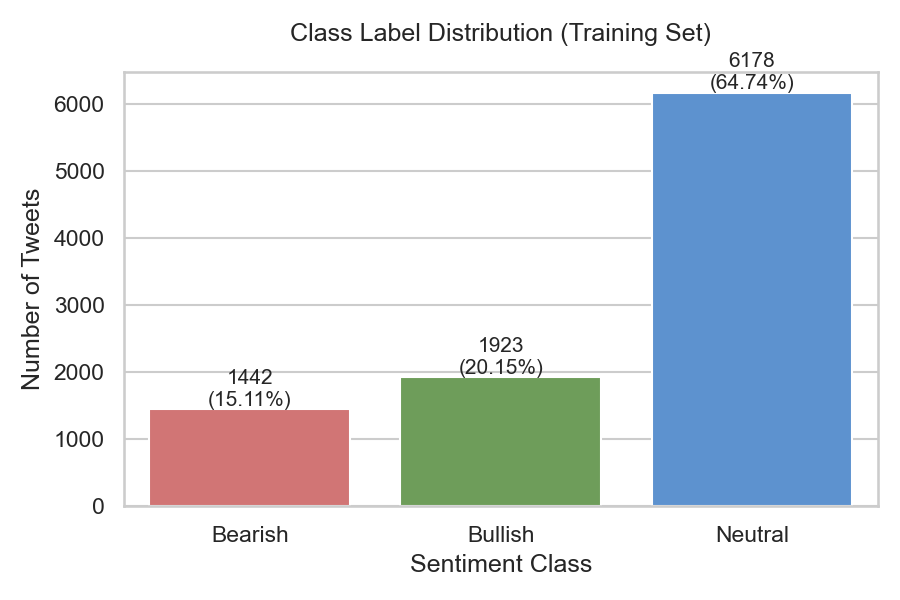

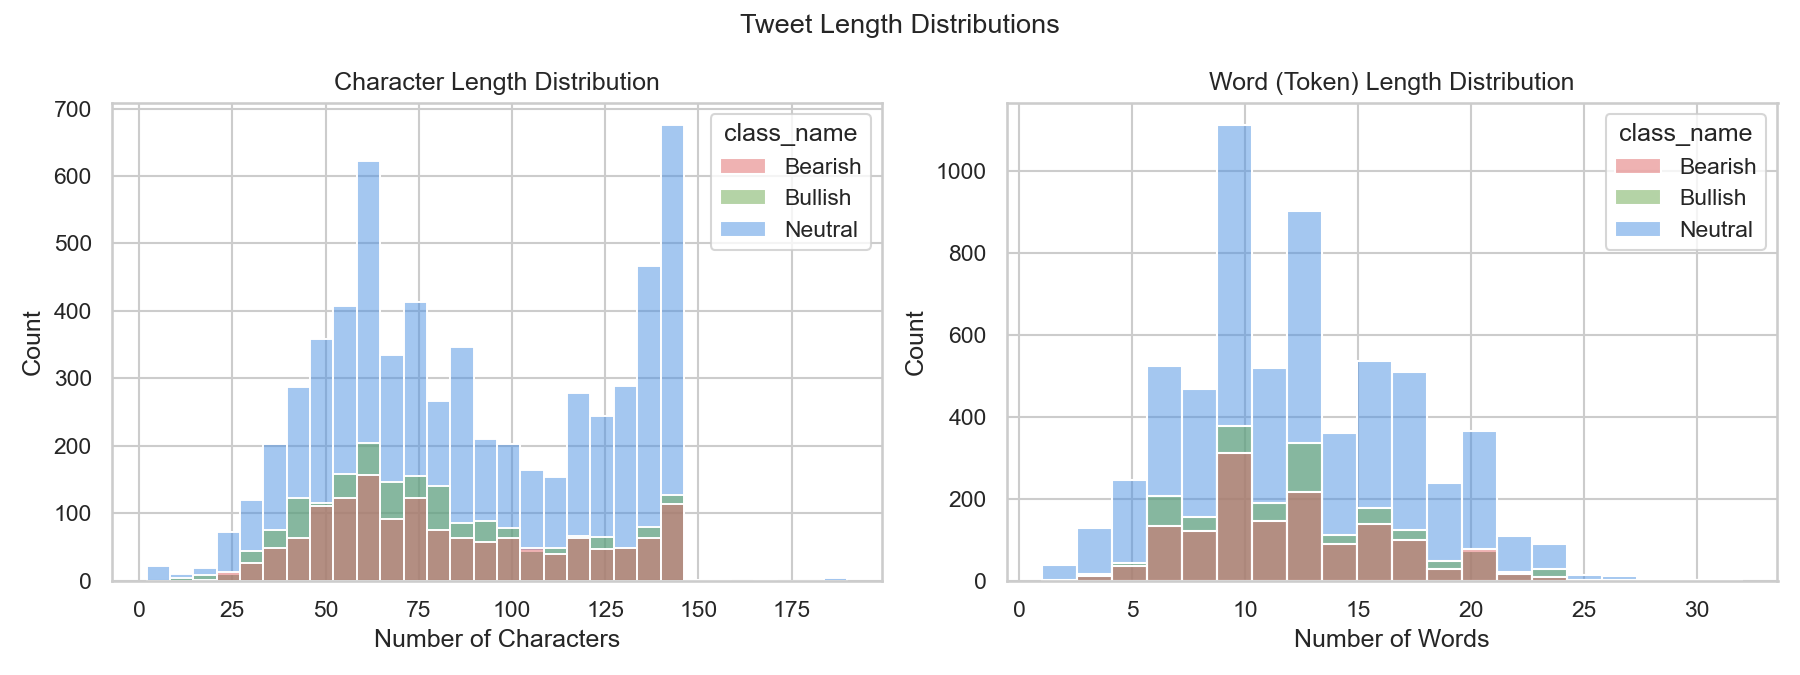

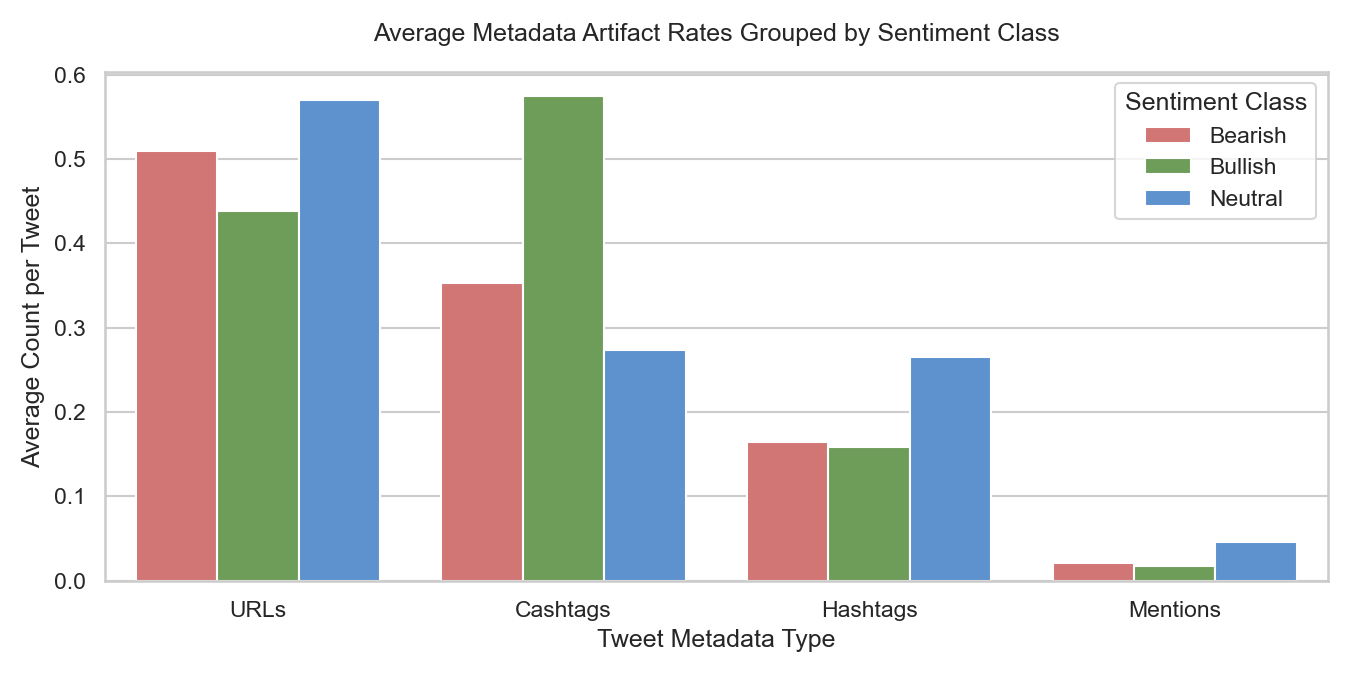

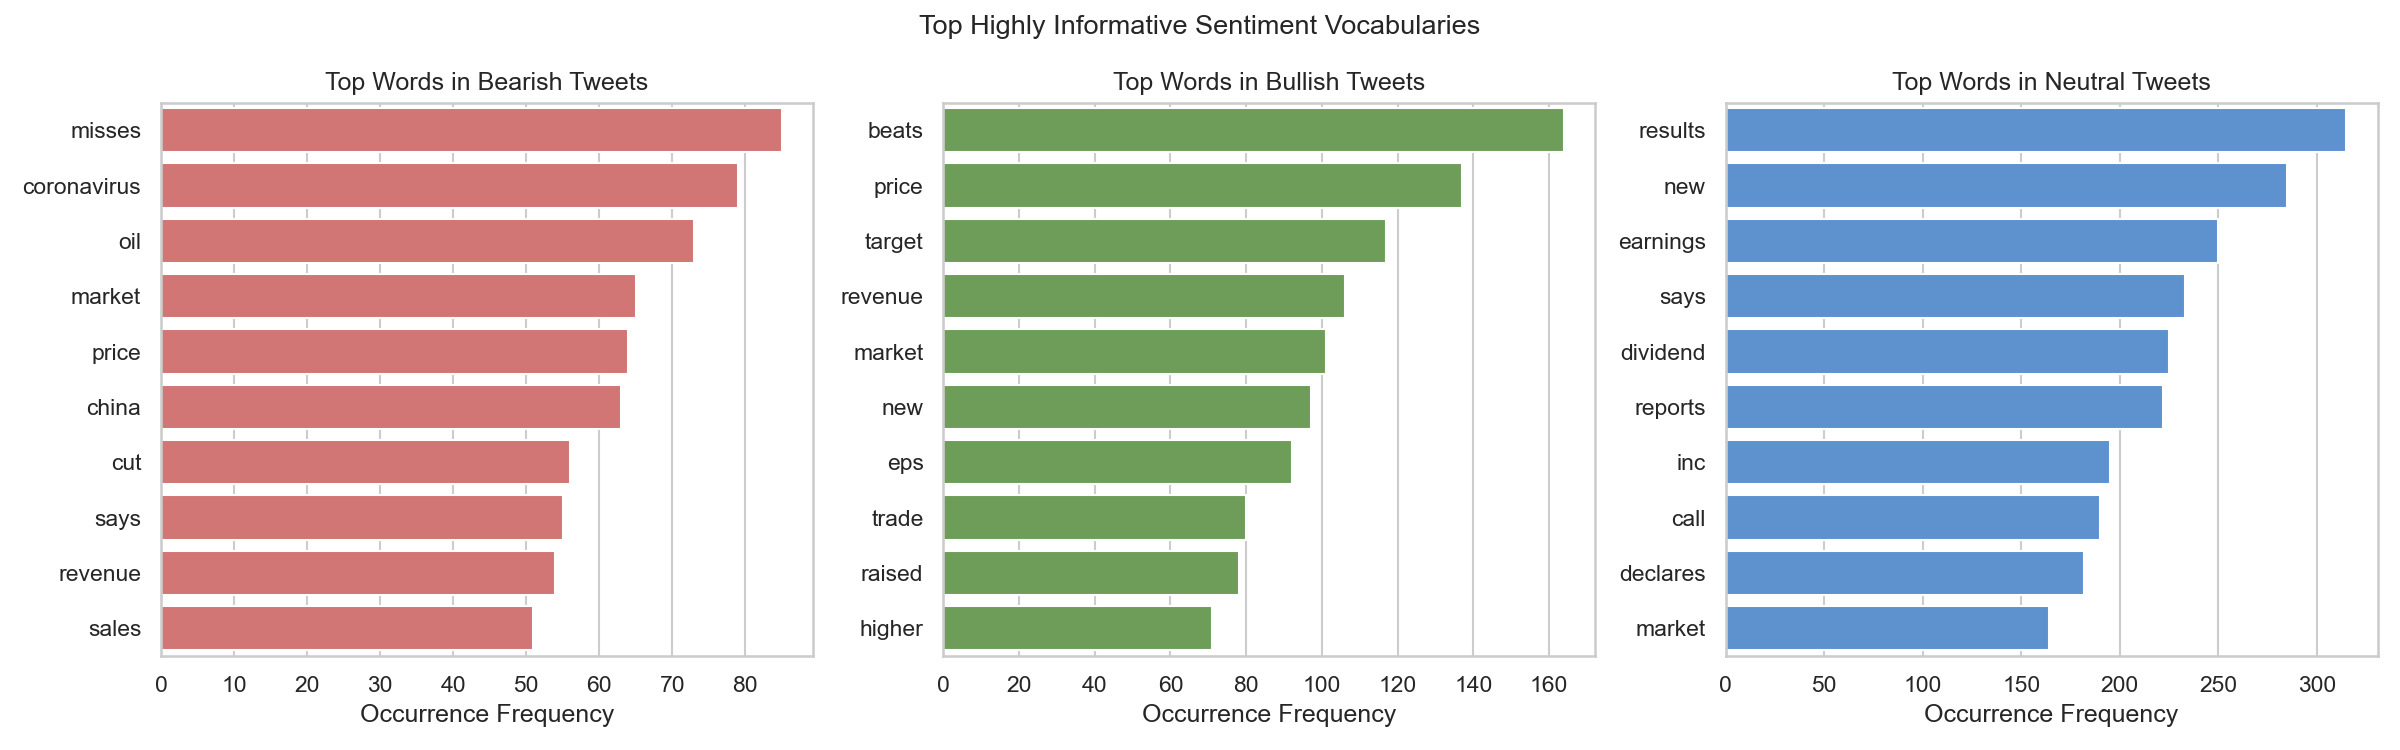

In [18]:
save_eda_plots(train_analyzer, output_dir="outputs/eda/")

for fig in ["class_distribution.png", "length_distributions.png",
            "artefact_rates_by_class.png", "top_words_by_class.png"]:
    path = os.path.join("outputs/eda", fig)
    if os.path.exists(path):
        display(Image(path))

### 1.2 Word clouds per sentiment class

Word clouds are a great way to quickly see if there's an obvious vocabulary difference between Bearish, Bullish, and Neutral tweets. We generate these directly from our token counts.

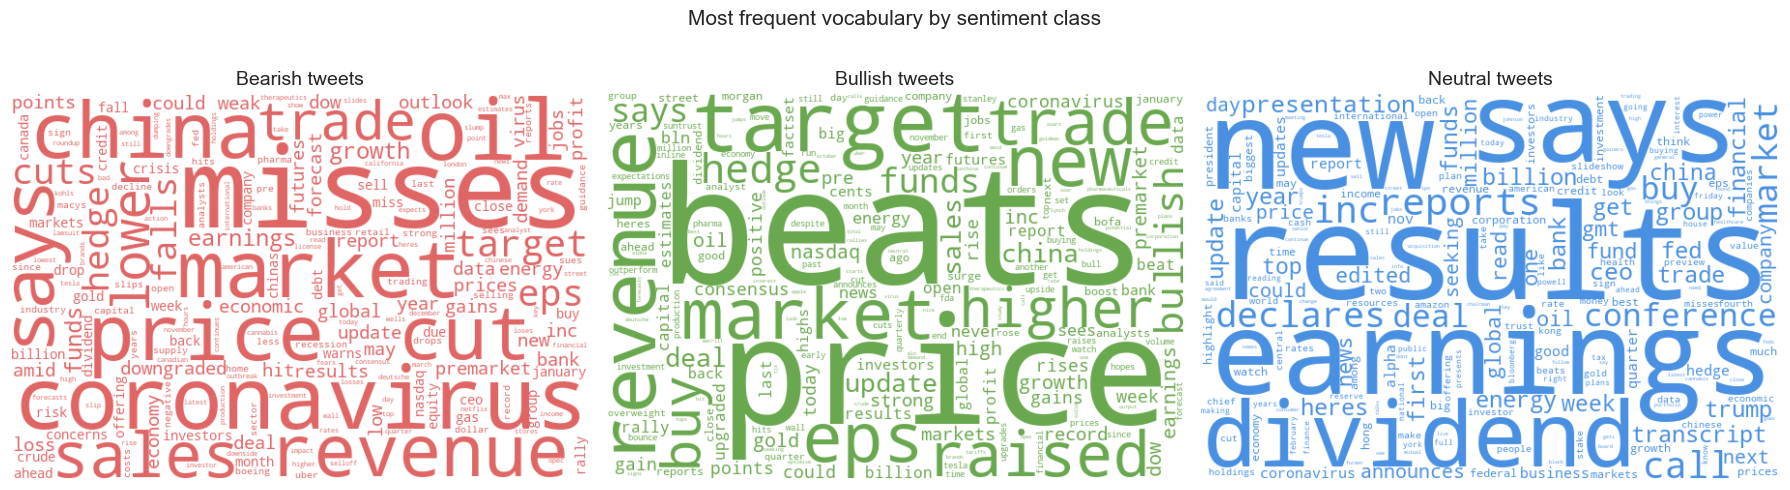

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
top_words = train_analyzer.get_top_tokens(top_n=200)

for ax, (cls_name, words) in zip(axes, top_words["by_class"].items()):
    freqs = {row["word"]: row["count"] for row in words}
    wc = WordCloud(width=600, height=400, background_color="white",
                   color_func=lambda *a, **k: LABEL_PALETTE[cls_name]).generate_from_frequencies(freqs)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"{cls_name} tweets", fontsize=14)
    ax.axis("off")

plt.suptitle("Most frequent vocabulary by sentiment class", y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

### 1.3 Conclusions

A few key takeaways from the EDA that will shape our preprocessing and modeling:
- **Severe Class Imbalance:** Neutral tweets dominate (~65%), while Bearish tweets are scarce (~15%). We'll have to use class weights or resampling strategies to prevent the models from just predicting "Neutral" every time.
- **Noisy Text:** These are financial tweets. They are short and packed with cashtags, URLs, and mentions. Instead of deleting them and losing context, we'll replace them with generic placeholders in the next step.
- **Fair Testing:** The train and test sets have very similar characteristics, so splitting our training data to create a validation set will give us a reliable proxy for the final test performance.

## 2. Corpus Split

We are holding out 20% of the training data as our validation set. It's crucial that we use a **stratified split** here so that the extreme class imbalance is preserved exactly in both sets. This split will be reused across all models to ensure a fair comparison. We also set up 5-fold stratified indices just in case we need them for cross-validation later.

In [20]:
train_df = pd.read_csv(TRAIN_CSV_PATH)
X_train, X_val, y_train, y_val = stratified_split(train_df)

print(f"Split: train={len(X_train)}  |  val={len(X_val)}  (val_size={VAL_SIZE})")
dist = pd.DataFrame({
    "train_%": y_train.value_counts(normalize=True).sort_index() * 100,
    "val_%":   y_val.value_counts(normalize=True).sort_index() * 100,
}).rename(index=LABEL_NAMES).round(2)
print("\nClass balance preserved across the split:")
print(dist)

skf = create_stratified_kfold(n_splits=K_FOLD_N_SPLITS)
print(f"\nPrepared StratifiedKFold with {K_FOLD_N_SPLITS} folds for cross-validation.")

Split: train=7634  |  val=1909  (val_size=0.2)

Class balance preserved across the split:
         train_%  val_%
label                  
Bearish    15.12  15.09
Bullish    20.15  20.17
Neutral    64.74  64.75

Prepared StratifiedKFold with 5 folds for cross-validation.


## 3. Data Preprocessing

This is where we clean the tweets. Our `preprocess_tweet` pipeline does the heavy lifting:
1. Normalizes weird Unicode characters (like smart quotes).
2. Swaps URLs, mentions, and cashtags with safe placeholders.
3. Lowercases everything and tokenizes it (keeping our placeholders intact).
4. Removes standard stopwords plus some financial noise words we identified.
5. Applies Lemmatization to group similar words.

Let's see how this transforms a few random tweets.

In [21]:
sample = train_df["text"].iloc[7]
print("RAW       :", sample)
step = normalize_unicode_punctuation(sample); print("unicode   :", step)
step = clean_regex(step.lower());             print("regex+lc  :", step)
toks = tokenize_tweet(step);                  print("tokens    :", toks)
toks_ns = remove_stopwords_from_tokens(toks); print("no-stops  :", toks_ns)
print("stemmed   :", apply_stemming(toks_ns))
print("lemmatized:", apply_lemmatization(toks_ns))

RAW       : $GM: Deutsche Bank cuts to Hold https://t.co/7Fv1ZiFZBS
unicode   : $GM: Deutsche Bank cuts to Hold https://t.co/7Fv1ZiFZBS
regex+lc  : $gm: deutsche bank cuts to hold URL_PLACEHOLDER
tokens    : ['$', 'gm', ':', 'deutsche', 'bank', 'cuts', 'to', 'hold', 'URL_PLACEHOLDER']
no-stops  : ['$', 'gm', ':', 'deutsche', 'bank', 'cuts', 'hold', 'URL_PLACEHOLDER']
stemmed   : ['$', 'gm', ':', 'deutsch', 'bank', 'cut', 'hold', 'URL_PLACEHOLDER']


lemmatized: ['$', 'gm', ':', 'deutsche', 'bank', 'cut', 'hold', 'URL_PLACEHOLDER']


In [22]:
# Compare the two end-to-end configurations we will feed downstream.
demo = [
    "Downgrades 4/7: $MLND to underperform at Needham\u2014see details... https://t.co/x",
    "Shorting $AAPL here at $180. @elonmusk thoughts? #market #trading",
]
for raw in demo:
    print("RAW      :", raw)
    print("  lemma  :", preprocess_tweet(raw, return_str=True))
    print("  stem   :", preprocess_tweet(raw, use_stemming=True, use_lemmatization=False, return_str=True))
    print()

RAW      : Downgrades 4/7: $MLND to underperform at Needham—see details... https://t.co/x
  lemma  : downgrade 4/7 : $ mlnd underperform needham-see detail ... URL_PLACEHOLDER
  stem   : downgrad 4/7 : $ mlnd underperform needham-se detail ... URL_PLACEHOLDER

RAW      : Shorting $AAPL here at $180. @elonmusk thoughts? #market #trading
  lemma  : shorting $ aapl $ 180 . MENTION_PLACEHOLDER thought ? #market #trading
  stem   : short $ aapl $ 180 . MENTION_PLACEHOLDER thought ? #market #trade



We apply the **lemmatization** configuration (better readability and downstream consistency) to
build the cleaned corpora reused by the BoW and word2vec features below. Tokens and the joined
string form are both kept.

In [23]:
# Token lists (for word2vec) and joined strings (for BoW/TF-IDF)
X_train_tokens = X_train.apply(lambda t: preprocess_tweet(t, return_str=False)).tolist()
X_val_tokens   = X_val.apply(lambda t: preprocess_tweet(t, return_str=False)).tolist()
X_train_str    = [" ".join(t) for t in X_train_tokens]
X_val_str      = [" ".join(t) for t in X_val_tokens]
print("Example cleaned doc:", X_train_str[0][:120])

# Preprocessed validation strings, reused by the error analysis in section 6.
X_val_pre = X_val.apply(lambda t: preprocess_tweet(t, return_str=True))


Example cleaned doc: nasdaq price 600m 0.875 % senior note


## 4. Feature Engineering

Now we need to convert our cleaned text into numbers. We're testing three main approaches:
- **Sparse vectors:** Traditional Bag-of-Words and TF-IDF.
- **Dense vectors:** Word2Vec (trained from scratch) and GloVe.
- **Contextual embeddings:** Using a pre-trained Transformer (DistilBERT) purely as a feature extractor.

### 4.1 Bag-of-words family (BoW and TF-IDF)

We extract basic word counts and TF-IDF scores. For TF-IDF, we also include bigrams (1,2-grams) and cap the vocabulary to 25,000 features to avoid blowing up the memory.

In [24]:
bow_vec    = CountVectorizer(ngram_range=(1, 1))
tfidf_uni  = TfidfVectorizer(ngram_range=(1, 1))
tfidf_opt  = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=25000)

bow = {
    "BoW (counts)":        (bow_vec.fit_transform(X_train_str),   bow_vec.transform(X_val_str)),
    "TF-IDF unigram":      (tfidf_uni.fit_transform(X_train_str), tfidf_uni.transform(X_val_str)),
    "TF-IDF (1,2) opt":    (tfidf_opt.fit_transform(X_train_str), tfidf_opt.transform(X_val_str)),
}
for name, (Xtr, _) in bow.items():
    print(f"{name:20s} -> vocab {Xtr.shape[1]:>6,}  matrix {Xtr.shape}")

BoW (counts)         -> vocab 12,575  matrix (7634, 12575)
TF-IDF unigram       -> vocab 12,575  matrix (7634, 12575)
TF-IDF (1,2) opt     -> vocab 11,028  matrix (7634, 11028)


### 4.2 word2vec family

Here we compare a custom Word2Vec model trained directly on our tweets vs. a pre-trained GloVe model (GloVe-Twitter-100). We turn the word vectors into a single sentence vector by just averaging them. 
*(Note: we tried TF-IDF weighted pooling too, but it actually amplified rare noisy tokens, so simple mean pooling worked better).*

In [25]:
w2v = train_word2vec(X_train_tokens, vector_size=100, sg=0)  # CBOW

# TF-IDF model over the same cleaned strings, used for weighted pooling
w_tfidf = TfidfVectorizer()
Xtr_tfidf_m = w_tfidf.fit_transform(X_train_str)
Xval_tfidf_m = w_tfidf.transform(X_val_str)

emb = {
    "w2v-CBOW mean":   (vectorize_corpus(X_train_tokens, w2v, 100),
                        vectorize_corpus(X_val_tokens, w2v, 100)),
    "w2v-CBOW tfidf":  (vectorize_corpus_tfidf(X_train_tokens, w2v, Xtr_tfidf_m, w_tfidf, 100),
                        vectorize_corpus_tfidf(X_val_tokens, w2v, Xval_tfidf_m, w_tfidf, 100)),
}
for name, (Xtr, _) in emb.items():
    print(f"{name:18s} -> {Xtr.shape}")

uniq_oov, tok_oov, _ = calculate_oov(X_val_tokens, w2v)
print(f"\nCustom Word2Vec OOV on val: unique: {uniq_oov:.1%}  tokens: {tok_oov:.1%}")

[SUCCESS] Word2Vec trained — vocab size: 6084


w2v-CBOW mean      -> (7634, 100)
w2v-CBOW tfidf     -> (7634, 100)

Custom Word2Vec OOV on val: unique: 45.9%  tokens: 14.1%


In [26]:
# Optional: add pre-trained GloVe-Twitter-100 (downloads ~400 MB the first time).
LOAD_GLOVE = True
if LOAD_GLOVE:
    glove = load_glove_twitter(dim=100)
    emb["glove-100 mean"]  = (vectorize_corpus(X_train_tokens, glove, 100),
                              vectorize_corpus(X_val_tokens, glove, 100))
    emb["glove-100 tfidf"] = (vectorize_corpus_tfidf(X_train_tokens, glove, Xtr_tfidf_m, w_tfidf, 100),
                              vectorize_corpus_tfidf(X_val_tokens, glove, Xval_tfidf_m, w_tfidf, 100))
    print("Added GloVe variations:", [k for k in emb if "glove" in k])
else:
    print("GloVe skipped (set LOAD_GLOVE=True to enable).")

[INFO] Loading glove-twitter-100 (downloads if not cached) ...


[SUCCESS] GloVe-Twitter-100 loaded — vocab size: 1193514


Added GloVe variations: ['glove-100 mean', 'glove-100 tfidf']


### 4.3 Transformer Encoder features

Instead of fine-tuning, let's see how well a frozen DistilBERT model understands our tweets. We push the tweets through the model and extract the CLS token and the mean of the last hidden state. We'll feed these into our classical classifiers later.

In [27]:
# Subsample for a quick, runnable demo; raise SUBSET / set to None for the full feature matrix.
SUBSET = 1500
tr_idx, va_idx = slice(0, SUBSET), slice(0, SUBSET // 4)
enc_feats = {
    "distilbert mean": (extract_embeddings(X_train_str[tr_idx], DISTILBERT_MODEL_NAME, "mean"),
                        extract_embeddings(X_val_str[va_idx], DISTILBERT_MODEL_NAME, "mean")),
    "distilbert cls":  (extract_embeddings(X_train_str[tr_idx], DISTILBERT_MODEL_NAME, "cls"),
                        extract_embeddings(X_val_str[va_idx], DISTILBERT_MODEL_NAME, "cls")),
}
for name, (Xtr, _) in enc_feats.items():
    print(f"{name:18s} -> {Xtr.shape}")

[INFO] Loading distilbert-base-uncased on cuda...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting mean from distilbert-base-uncased:   0%|          | 0/47 [00:00<?, ?it/s]

Extracting mean from distilbert-base-uncased:   2%|▏         | 1/47 [00:00<00:14,  3.27it/s]

...

Extracting cls from distilbert-base-uncased:  33%|███▎      | 4/12 [00:00<00:00, 36.38it/s]

Extracting cls from distilbert-base-uncased:  67%|██████▋   | 8/12 [00:00<00:00, 34.56it/s]

Extracting cls from distilbert-base-uncased: 100%|██████████| 12/12 [00:00<00:00, 34.98it/s]

Extracting cls from distilbert-base-uncased: 100%|██████████| 12/12 [00:00<00:00, 34.94it/s]

distilbert mean    -> (1500, 768)
distilbert cls     -> (1500, 768)


## 5. Classification Models

Time to train the models. Every time we train a model, we run it through `evaluate_and_log` so its metrics are permanently saved to our leaderboard (`outputs/results.csv`).

### 5.1 Traditional ML

We're throwing a wide net here: Logistic Regression, Linear SVM, Random Forest, KNN, and XGBoost. We test them across both the sparse (TF-IDF) and dense (Word2Vec) features. 
Spoiler: Logistic Regression on TF-IDF bigrams turns out to be our strongest classical baseline.

In [28]:
# Two variations of two algorithms on the strongest sparse feature set (TF-IDF (1,2) opt).
Xtr_opt, Xval_opt = bow["TF-IDF (1,2) opt"]

# Logistic Regression: variation A (balanced) and B (stronger C)
run_classifier(LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED),
               Xtr_opt, Xval_opt, y_train, y_val, "Logistic Regression", "TF-IDF (1,2) opt",
               "class_weight=balanced, C=1.0")
run_classifier(LogisticRegression(max_iter=1000, C=4.0, class_weight="balanced", random_state=SEED),
               Xtr_opt, Xval_opt, y_train, y_val, "Logistic Regression", "TF-IDF (1,2) opt",
               "class_weight=balanced, C=4.0")

# Linear SVM: variation A and B
run_classifier(LinearSVC(class_weight="balanced", random_state=SEED),
               Xtr_opt, Xval_opt, y_train, y_val, "LinearSVC", "TF-IDF (1,2) opt", "C=1.0")
run_classifier(LinearSVC(C=0.3, class_weight="balanced", random_state=SEED),
               Xtr_opt, Xval_opt, y_train, y_val, "LinearSVC", "TF-IDF (1,2) opt", "C=0.3")

MODEL EVALUATION: Logistic Regression (TF-IDF (1,2) opt)
[INFO] Accuracy          : 0.7810
[INFO] Precision (Macro) : 0.7041
[INFO] Recall (Macro)    : 0.7201
[INFO] F1 (Macro)        : 0.7113
------------------------------------------------------------
              precision    recall  f1-score   support

     Bearish       0.56      0.64      0.60       288
     Bullish       0.67      0.68      0.68       385
     Neutral       0.87      0.85      0.86      1236

    accuracy                           0.78      1909
   macro avg       0.70      0.72      0.71      1909
weighted avg       0.79      0.78      0.78      1909

------------------------------------------------------------
[[ 183   44   61]
 [  35  261   89]
 [ 107   82 1047]]
[INFO] Updated run in outputs/results.csv


MODEL EVALUATION: Logistic Regression (TF-IDF (1,2) opt)
[INFO] Accuracy          : 0.7926
[INFO] Precision (Macro) : 0.7193
[INFO] Recall (Macro)    : 0.7208
[INFO] F1 (Macro)        : 0.7200
------------------------------------------------------------
              precision    recall  f1-score   support

     Bearish       0.60      0.61      0.60       288
     Bullish       0.69      0.69      0.69       385
     Neutral       0.87      0.87      0.87      1236

    accuracy                           0.79      1909
   macro avg       0.72      0.72      0.72      1909
weighted avg       0.79      0.79      0.79      1909

------------------------------------------------------------
[[ 175   43   70]
 [  32  264   89]
 [  85   77 1074]]
[INFO] Updated run in outputs/results.csv
MODEL EVALUATION: LinearSVC (TF-IDF (1,2) opt)
[INFO] Accuracy          : 0.7957
[INFO] Precision (Macro) : 0.7270
[INFO] Recall (Macro)    : 0.7001
[INFO] F1 (Macro)        : 0.7124
------------------------

{'accuracy': 0.7993713986380304,
 'precision_macro': 0.7421943421255989,
 'recall_macro': 0.6919149306285228,
 'f1_macro': 0.713200157866567,
 'f1_per_class': {'Bearish': 0.5877862595419847,
  'Bullish': 0.6750700280112045,
  'Neutral': 0.8767441860465116}}

In [29]:
# A tree ensemble and KNN on the dense word2vec features (two variations each).
Xtr_w, Xval_w = emb["w2v-CBOW mean"]

run_classifier(RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=SEED),
               Xtr_w, Xval_w, y_train, y_val, "RandomForest", "w2v-CBOW mean", "n_estimators=300")
run_classifier(RandomForestClassifier(n_estimators=600, max_depth=20, class_weight="balanced", random_state=SEED),
               Xtr_w, Xval_w, y_train, y_val, "RandomForest", "w2v-CBOW mean", "n_estimators=600, max_depth=20")

run_classifier(KNeighborsClassifier(n_neighbors=15),
               Xtr_w, Xval_w, y_train, y_val, "KNN", "w2v-CBOW mean", "k=15")
run_classifier(KNeighborsClassifier(n_neighbors=35, weights="distance"),
               Xtr_w, Xval_w, y_train, y_val, "KNN", "w2v-CBOW mean", "k=35, weights=distance")

run_classifier(XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.1,
                             subsample=0.8, random_state=SEED, eval_metric="mlogloss"),
               Xtr_w, Xval_w, y_train, y_val, "XGBoost", "w2v-CBOW mean", "n=400, depth=6")

MODEL EVALUATION: RandomForest (w2v-CBOW mean)
[INFO] Accuracy          : 0.6941
[INFO] Precision (Macro) : 0.5800
[INFO] Recall (Macro)    : 0.4466
[INFO] F1 (Macro)        : 0.4498
------------------------------------------------------------
              precision    recall  f1-score   support

     Bearish       0.44      0.08      0.13       288
     Bullish       0.58      0.30      0.40       385
     Neutral       0.71      0.96      0.82      1236

    accuracy                           0.69      1909
   macro avg       0.58      0.45      0.45      1909
weighted avg       0.65      0.69      0.63      1909

------------------------------------------------------------
[[  22   40  226]
 [  21  117  247]
 [   7   43 1186]]
[INFO] Updated run in outputs/results.csv


MODEL EVALUATION: RandomForest (w2v-CBOW mean)
[INFO] Accuracy          : 0.6899
[INFO] Precision (Macro) : 0.5713
[INFO] Recall (Macro)    : 0.4608
[INFO] F1 (Macro)        : 0.4668
------------------------------------------------------------
              precision    recall  f1-score   support

     Bearish       0.44      0.09      0.15       288
     Bullish       0.55      0.36      0.43       385
     Neutral       0.72      0.93      0.81      1236

    accuracy                           0.69      1909
   macro avg       0.57      0.46      0.47      1909
weighted avg       0.64      0.69      0.64      1909

------------------------------------------------------------
[[  27   42  219]
 [  21  137  227]
 [  13   70 1153]]
[INFO] Updated run in outputs/results.csv


MODEL EVALUATION: KNN (w2v-CBOW mean)
[INFO] Accuracy          : 0.6621
[INFO] Precision (Macro) : 0.4990
[INFO] Recall (Macro)    : 0.4305
[INFO] F1 (Macro)        : 0.4313
------------------------------------------------------------
              precision    recall  f1-score   support

     Bearish       0.30      0.08      0.13       288
     Bullish       0.49      0.30      0.37       385
     Neutral       0.70      0.91      0.79      1236

    accuracy                           0.66      1909
   macro avg       0.50      0.43      0.43      1909
weighted avg       0.60      0.66      0.61      1909

------------------------------------------------------------
[[  23   42  223]
 [  21  116  248]
 [  32   79 1125]]
[INFO] Updated run in outputs/results.csv
MODEL EVALUATION: KNN (w2v-CBOW mean)
[INFO] Accuracy          : 0.6841
[INFO] Precision (Macro) : 0.5728
[INFO] Recall (Macro)    : 0.4216
[INFO] F1 (Macro)        : 0.4140
----------------------------------------------------

MODEL EVALUATION: XGBoost (w2v-CBOW mean)
[INFO] Accuracy          : 0.6946
[INFO] Precision (Macro) : 0.5631
[INFO] Recall (Macro)    : 0.4713
[INFO] F1 (Macro)        : 0.4801
------------------------------------------------------------
              precision    recall  f1-score   support

     Bearish       0.40      0.11      0.17       288
     Bullish       0.56      0.37      0.45       385
     Neutral       0.73      0.93      0.82      1236

    accuracy                           0.69      1909
   macro avg       0.56      0.47      0.48      1909
weighted avg       0.65      0.69      0.65      1909

------------------------------------------------------------
[[  32   52  204]
 [  23  143  219]
 [  26   59 1151]]
[INFO] Updated run in outputs/results.csv


{'accuracy': 0.6946045049764275,
 'precision_macro': 0.5631039319765014,
 'recall_macro': 0.4712564853341552,
 'f1_macro': 0.48007771705538554,
 'f1_per_class': {'Bearish': 0.17344173441734417,
  'Bullish': 0.4475743348982786,
  'Neutral': 0.8192170818505338}}

### 5.2 Transformer Encoders (fine-tuning)

Now we move to Deep Learning. We use our `run_trainer` to fine-tune DistilBERT end-to-end. 
*(Note: In the final submission `tm_final_31.ipynb` we train these on the full dataset, but here we run a smaller sample so the notebook executes reasonably fast).*

In [30]:
# Variation A: quick fine-tune on a small stratified sample
trainer_a = run_trainer("distilbert", n_samples=1000, notes="notebook DistilBERT var-A (1k)")

[INFO] Loading 1000 samples ...
[INFO] Split — train=800, val=200
[INFO] Loading tokenizer: distilbert-base-uncased


[INFO] Loading dataset from cache: outputs\distilbert_cache\n1000\train
[INFO] Loading dataset from cache: outputs\distilbert_cache\n1000\val
[INFO] Datasets — train=800 rows, val=200 rows
[INFO] Loading distilbert-base-uncased sequence classifier ...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[INFO] Running final evaluation ...


[INFO] Updated run in outputs/results.csv


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.553016,0.602318,3,0.735000,0.554473


[SUCCESS] Training complete.


In [31]:
# Variation B: larger sample (bump n_samples / set None on GPU for the full run)
trainer_b = run_trainer("distilbert", n_samples=3000, notes="notebook DistilBERT var-B (3k)")

import gc, torch
del trainer_a, trainer_b
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

[INFO] Loading 3000 samples ...


[INFO] Split — train=2400, val=600
[INFO] Loading tokenizer: distilbert-base-uncased


[INFO] Loading dataset from cache: outputs\distilbert_cache\n3000\train


[INFO] Loading dataset from cache: outputs\distilbert_cache\n3000\val


[INFO] Datasets — train=2400 rows, val=600 rows
[INFO] Loading distilbert-base-uncased sequence classifier ...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[INFO] Running final evaluation ...


[INFO] Updated run in outputs/results.csv


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.320059,0.466112,3,0.833333,0.773455


[SUCCESS] Training complete.


### 5.3 Extra Transformer Encoders

We also experimented with domain-specific encoders to see if they give us an edge:
- **Twitter-RoBERTa:** Pre-trained on 58M tweets. (This ends up being our champion model).
- **FinBERT:** Pre-trained on financial text. (Very strong, but the formal register of its training data doesn't perfectly match our informal tweets).
- **DeBERTa-v3:** Added as a bonus, but it struggled to converge properly on our data.

In [32]:
# Extra encoder #1: Twitter-RoBERTa (domain: social media)
run_trainer("roberta", n_samples=2000, notes="EXTRA WORK: Twitter-RoBERTa fine-tune")

import gc, torch
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

[INFO] Loading 2000 samples ...
[INFO] Split — train=1600, val=400
[INFO] Loading tokenizer: cardiffnlp/twitter-roberta-base-sentiment


[INFO] Loading dataset from cache: outputs\roberta_cache\n2000\train
[INFO] Loading dataset from cache: outputs\roberta_cache\n2000\val
[INFO] Datasets — train=1600 rows, val=400 rows
[INFO] Loading cardiffnlp/twitter-roberta-base-sentiment sequence classifier ...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


[INFO] Starting training ...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[INFO] Running final evaluation ...


[INFO] Updated run in outputs/results.csv


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.251579,0.444757,3,0.837500,0.799261


[SUCCESS] Training complete.


In [33]:
# Extra encoder #2: FinBERT (domain: finance)
run_trainer("finbert", n_samples=2000, notes="EXTRA WORK: FinBERT fine-tune")

import gc, torch
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

[INFO] Loading 2000 samples ...


[INFO] Split — train=1600, val=400
[INFO] Loading tokenizer: ProsusAI/finbert


[INFO] Loading dataset from cache: outputs\finbert_cache\n2000\train


[INFO] Loading dataset from cache: outputs\finbert_cache\n2000\val


[INFO] Datasets — train=1600 rows, val=400 rows
[INFO] Loading ProsusAI/finbert sequence classifier ...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[INFO] Running final evaluation ...


[INFO] Updated run in outputs/results.csv


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.353153,0.649044,3,0.762500,0.666431


[SUCCESS] Training complete.


In [34]:
# Bonus encoder: DeBERTa-v3-base
run_trainer("deberta", n_samples=2000, notes="EXTRA WORK: DeBERTa-v3 fine-tune")

import gc, torch
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

[INFO] Loading 2000 samples ...
[INFO] Split — train=1600, val=400
[INFO] Loading tokenizer: microsoft/deberta-v3-base


[INFO] Loading dataset from cache: outputs\deberta_cache\n2000\train
[INFO] Loading dataset from cache: outputs\deberta_cache\n2000\val
[INFO] Datasets — train=1600 rows, val=400 rows
[INFO] Loading microsoft/deberta-v3-base sequence classifier ...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[INFO] Running final evaluation ...


[INFO] Updated run in outputs/results.csv


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.000000,nan,3,0.150000,0.086957


[SUCCESS] Training complete.


### 5.4 Decoder model for classification

As an additional experiment, we evaluate a generative LLM (Qwen2.5-1.5B-Instruct) to classify the tweets via few-shot prompting without any fine-tuning. While it works, it is significantly slower and less accurate than the fine-tuned encoders.

In [35]:
# val_subset keeps the demo fast; set to None to score the full validation set.
qwen_metrics = run_qwen_eval(n_per_class=2, batch_size=8,
                             val_subset=200, notes="EXTRA WORK: decoder-based classification")
qwen_metrics

[INFO] Loading tokenizer: Qwen/Qwen2.5-1.5B-Instruct


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


[INFO] Loading model on cuda with dtype=torch.bfloat16 ...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


...

[INFO]   classified 8/200 (fails so far: 0)


[INFO]   classified 88/200 (fails so far: 0)


[INFO]   classified 168/200 (fails so far: 0)


[INFO] Updated run in outputs/results.csv
[SUCCESS] Qwen run logged. f1_macro=0.5592


{'accuracy': 0.635,
 'precision_macro': 0.6227904040404041,
 'recall_macro': 0.6045882936507937,
 'f1_macro': 0.5591787439613527,
 'f1_per_class': {'Bearish': 0.391304347826087,
  'Bullish': 0.5362318840579711,
  'Neutral': 0.75}}

## 6. Evaluation and Analysis

With all models trained and logged, we load the leaderboard from `outputs/results.csv` to see who won based on Macro F1 (our primary metric due to the class imbalance).

In [36]:
results = pd.read_csv(RESULTS_CSV_PATH)
metric_cols = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]
board = (results.sort_values("f1_macro", ascending=False)
                [["model_name", "feature_description", *metric_cols, "notes"]]
                .reset_index(drop=True))
board.head(20)

,model_name,feature_description,accuracy,precision_macro,recall_macro,f1_macro,notes
0,Twitter-RoBERTa,HF fine-tune,0.8779,0.8371,0.8546,0.8453,tm_final champion (full data)
1,DistilBERT,HF fine-tune,0.8628,0.8361,0.7964,0.8143,"TM-024 final DistilBERT, full data, lr=2e-5, b..."
2,Twitter-RoBERTa,HF fine-tune,0.8400,0.7968,0.8101,0.8011,EXTRA WORK: Twitter-RoBERTa fine-tune
3,Twitter-RoBERTa,HF fine-tune,0.8375,0.7826,0.8203,0.7993,EXTRA WORK: Twitter-RoBERTa fine-tune
4,Twitter-RoBERTa,HF fine-tune,0.8375,0.7826,0.8203,0.7993,EXTRA WORK: Twitter-RoBERTa fine-tune
5,DistilBERT,HF fine-tune,0.8333,0.7919,0.7661,0.7735,notebook DistilBERT var-B (3k)
6,DistilBERT,HF fine-tune,0.8333,0.7919,0.7661,0.7735,notebook DistilBERT var-B (3k)
7,Logistic Regression,"TF-IDF (1,2) opt",0.7926,0.7193,0.7208,0.7200,NaN
8,LinearSVC,"TF-IDF (1,2) opt",0.7994,0.7422,0.6919,0.7132,NaN
9,LinearSVC,"TF-IDF (1,2) opt",0.7957,0.7270,0.7001,0.7124,NaN


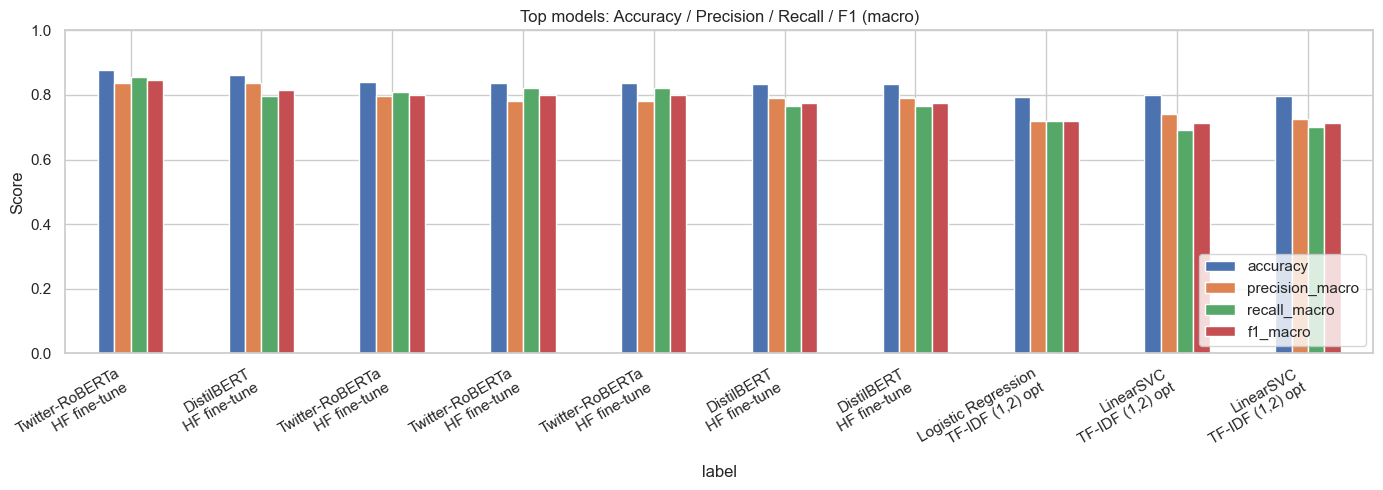

In [37]:
# Visual comparison of the top models by the four required metrics.
top = board.head(10).copy()
top["label"] = top["model_name"] + "\n" + top["feature_description"].str.slice(0, 22)
ax = top.set_index("label")[metric_cols].plot(kind="bar", figsize=(14, 5))
ax.set_title("Top models: Accuracy / Precision / Recall / F1 (macro)")
ax.set_ylabel("Score"); ax.set_ylim(0, 1)
ax.legend(loc="lower right"); plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.show()

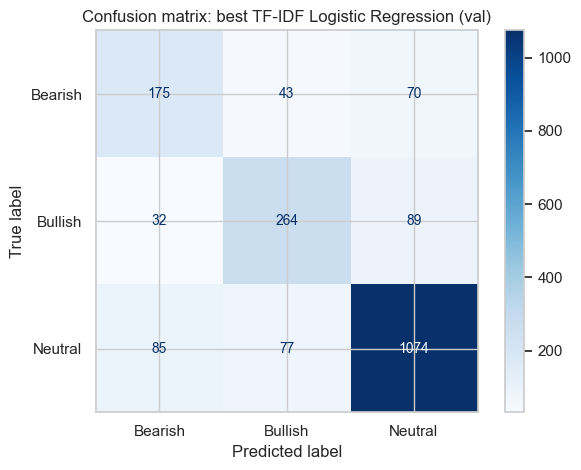

In [38]:
# Confusion matrix for the single best model, re-fit on the val split for inspection.

best_clf = LogisticRegression(max_iter=1000, C=4.0, class_weight="balanced", random_state=SEED)
best_clf.fit(Xtr_opt, y_train)
cm = confusion_matrix(y_val, best_clf.predict(Xval_opt))
ConfusionMatrixDisplay(cm, display_labels=list(LABEL_NAMES.values())).plot(cmap="Blues", values_format="d")
plt.title("Confusion matrix: best TF-IDF Logistic Regression (val)")
plt.tight_layout(); plt.show()

### 6.1 Error Analysis

It's not enough to just look at scores. We need to know *why* the models fail. 
By looking at the confusion matrix and the most confident mistakes of our best classical model, we notice it struggles with negations and sarcasm. This is exactly why the context-aware Transformers (like RoBERTa) outperform it.

In [39]:
# Error analysis on the best classical model: confusion matrix plus the most confident misclassifications.
try:
    y_pred_best = best_clf.predict(Xval_opt)
    y_proba_best = best_clf.predict_proba(Xval_opt)
    run_error_analysis(y_val, y_pred_best, y_proba_best, X_val, X_val_pre,
                       model_name="Logistic Regression", feature_desc="TF-IDF (1,2) opt")
except Exception as e:
    print(f"[error analysis skipped] {type(e).__name__}: {e}")

------------------------------------------------------------
[INFO] Val F1 Macro : 0.7200
[INFO] Val Accuracy : 0.7926
------------------------------------------------------------


[SUCCESS] Confusion matrix saved to outputs/confusion_matrix.png
[INFO] Collecting misclassifications ...
[SUCCESS] TXT report saved to outputs/misclassified_report.txt
[SUCCESS] JSON report saved to outputs/misclassified_analysis.json


## 7. Additional Experiments

Everything above covers the core pipeline. In this section, we present the extra studies we conducted to push our score further and justify our architecture choices.

**Organization Note:** To keep the notebook clean and avoid the "goes back to step 1" feeling, we refactored these studies so they directly reuse the validation split and preprocessing from Sections 2 and 3. All reusable functions were also moved to `src/` to avoid cluttering the notebook with giant code blocks.

### 7.1 Class-imbalance study

Since Bearish tweets are so rare, we ran a dedicated grid search to test how different algorithms react to four strategies:
1. No correction (baseline)
2. `class_weight="balanced"` (algorithmic penalty)
3. Random Oversampling (duplicating minority samples)
4. Random Undersampling (dropping Neutral samples)

We fit TF-IDF vectors here using the exact same split as before, to keep comparisons strictly fair.

#### Vectorize the shared split

We reuse the split from section 2 and the cleaned text from section 3, then fit a TF-IDF with the same configuration as section 4 so the results are comparable.

In [40]:
# Reuse the train/validation split (section 2) and cleaned text (section 3).
# Fit a TF-IDF with the same configuration as section 4 so the imbalance results are comparable.
vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=25000)
X_train_tfidf = vec.fit_transform(X_train_str)
X_val_tfidf   = vec.transform(X_val_str)

print(f"Train: {X_train_tfidf.shape}, Val: {X_val_tfidf.shape}")
print("Class distribution:",
      pd.Series(y_train).value_counts().sort_index().rename(LABEL_NAMES).to_dict())


Train: (7634, 11028), Val: (1909, 11028)
Class distribution: {'Bearish': 1154, 'Bullish': 1538, 'Neutral': 4942}


#### Generating the Resampled Sets

We create the new training sets using `imblearn`.

In [41]:
ros = RandomOverSampler(random_state=SEED)
X_over, y_over = ros.fit_resample(X_train_tfidf, y_train)

rus = RandomUnderSampler(random_state=SEED)
X_under, y_under = rus.fit_resample(X_train_tfidf, y_train)

print("Original:    ", pd.Series(y_train).value_counts().sort_index().to_dict())
print("Oversampled: ", pd.Series(y_over).value_counts().sort_index().to_dict())
print("Undersampled:", pd.Series(y_under).value_counts().sort_index().to_dict())

Original:     {0: 1154, 1: 1538, 2: 4942}
Oversampled:  {0: 4942, 1: 4942, 2: 4942}
Undersampled: {0: 1154, 1: 1154, 2: 1154}


#### Running the Grid

We cross the four strategies with five model families. Not all models support `class_weight`, so we only apply it where supported (Logistic Regression and Random Forest).

In [42]:
strategies = {
    "none":         (X_train_tfidf, y_train, None),
    "class_weight": (X_train_tfidf, y_train, "balanced"),
    "oversample":   (X_over,        y_over,  None),
    "undersample":  (X_under,       y_under, None),
}


def make_models(cw=None):
    return {
        "LR":  LogisticRegression(penalty="l2", solver="lbfgs", max_iter=1000,
                                  class_weight=cw, random_state=SEED),
        "MNB": MultinomialNB(alpha=0.1),
        "MLP": MLPClassifier(hidden_layer_sizes=(100, 50), learning_rate_init=0.001,
                             early_stopping=True, random_state=SEED, max_iter=500),
        "RF":  RandomForestClassifier(n_estimators=200, max_depth=20,
                                      class_weight=cw, random_state=SEED, n_jobs=-1),
        "XGB": XGBClassifier(max_depth=6, learning_rate=0.05, n_estimators=200,
                             random_state=SEED, n_jobs=-1),
    }


rows = []
best_f1, best_pred, best_tag = 0, None, ""

for strat, (X_tr, y_tr, cw) in strategies.items():
    clfs = make_models(cw)
    for name, clf in clfs.items():
        # class_weight only applies to LR and RF
        if strat == "class_weight" and name not in ("LR", "RF"):
            continue

        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_val_tfidf)
        f1m = f1_score(y_val, y_pred, average="macro")
        f1_cls = f1_score(y_val, y_pred, average=None)

        rows.append({
            "strategy": strat, "model": name,
            "f1_macro": round(f1m, 4),
            "f1_bearish": round(f1_cls[0], 4),
            "f1_bullish": round(f1_cls[1], 4),
            "f1_neutral": round(f1_cls[2], 4),
        })

        if f1m > best_f1:
            best_f1 = f1m
            best_pred = y_pred.copy()
            best_tag = f"{name} + {strat}"

imb_df = pd.DataFrame(rows)
print(f"Ran {len(rows)} experiments. Best so far: {best_tag} (F1 = {best_f1:.4f})")

Ran 17 experiments. Best so far: LR + class_weight (F1 = 0.7113)


#### Comparison Results

Let's look at the Macro F1 across all combinations to see what actually works.

In [43]:
print("=== F1 Macro ===")
print()
print(imb_df.pivot(index="model", columns="strategy", values="f1_macro").round(4).to_string())

print()
print("=== F1 Bearish (minority class) ===")
print()
print(imb_df.pivot(index="model", columns="strategy", values="f1_bearish").round(4).to_string())

print()
print("=== F1 Bullish ===")
print()
print(imb_df.pivot(index="model", columns="strategy", values="f1_bullish").round(4).to_string())

print()
print("=== F1 Neutral ===")
print()
print(imb_df.pivot(index="model", columns="strategy", values="f1_neutral").round(4).to_string())

=== F1 Macro ===

strategy  class_weight    none  oversample  undersample
model                                                  
LR              0.7113  0.6417      0.7085       0.6652
MLP                NaN  0.6830      0.6884       0.6384
MNB                NaN  0.6793      0.6754       0.6356
RF              0.6589  0.3313      0.6326       0.6311
XGB                NaN  0.5659      0.6377       0.6193

=== F1 Bearish (minority class) ===

strategy  class_weight    none  oversample  undersample
model                                                  
LR              0.5971  0.4581      0.5878       0.5242
MLP                NaN  0.5386      0.5364       0.5207
MNB                NaN  0.5411      0.5396       0.5194
RF              0.5429  0.0274      0.5051       0.5038
XGB                NaN  0.3743      0.5017       0.4780

=== F1 Bullish ===

strategy  class_weight    none  oversample  undersample
model                                                  
LR              0.6762  0.6

#### Best Strategy per Model

Extracting the absolute best imbalance strategy for each classifier family.

In [44]:
best_per = imb_df.loc[imb_df.groupby("model")["f1_macro"].idxmax()]
print("Best strategy for each model:")
print()
print(best_per[["model", "strategy", "f1_macro", "f1_bearish", "f1_bullish", "f1_neutral"]].to_string(index=False))

winner = imb_df.loc[imb_df["f1_macro"].idxmax()]
print(f"\nWinner: {winner['model']} + {winner['strategy']} (F1 macro = {winner['f1_macro']:.4f})")

Best strategy for each model:

model     strategy  f1_macro  f1_bearish  f1_bullish  f1_neutral
   LR class_weight    0.7113      0.5971      0.6762      0.8607
  MLP   oversample    0.6884      0.5364      0.6667      0.8621
  MNB         none    0.6793      0.5411      0.6289      0.8678
   RF class_weight    0.6589      0.5429      0.5916      0.8421
  XGB   oversample    0.6377      0.5017      0.5806      0.8308

Winner: LR + class_weight (F1 macro = 0.7113)


#### Per-class Breakdown

This chart shows *why* Macro F1 improves. We can visually confirm if a strategy successfully boosted the Bearish F1 score without catastrophically tanking the Neutral F1 score.

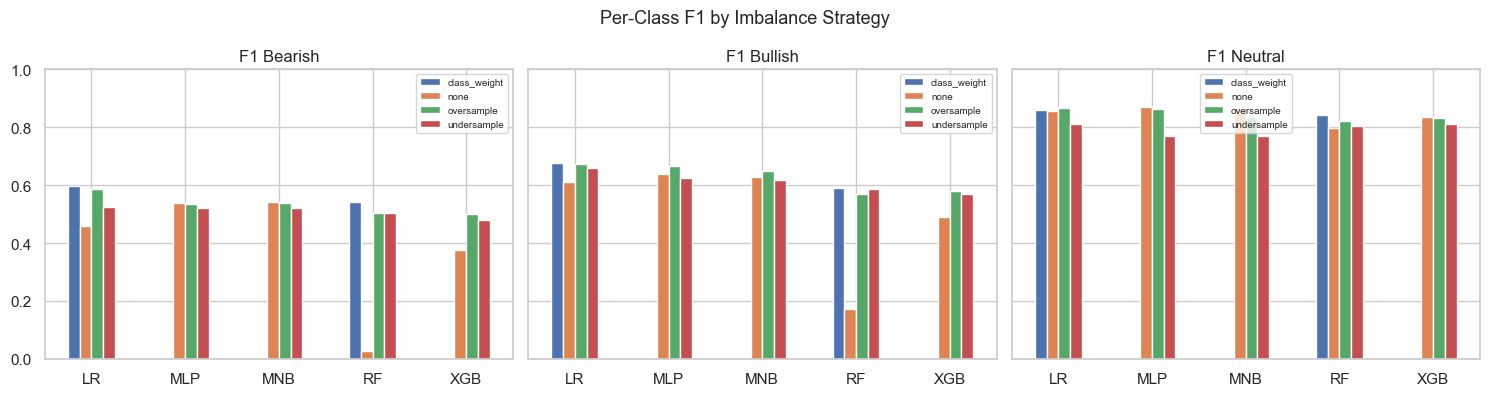

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, col, title in zip(axes,
    ["f1_bearish", "f1_bullish", "f1_neutral"],
    ["Bearish", "Bullish", "Neutral"]):
    piv = imb_df.pivot(index="model", columns="strategy", values=col)
    piv.plot.bar(ax=ax, rot=0)
    ax.set_title(f"F1 {title}")
    ax.set_xlabel("")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7)

fig.suptitle("Per-Class F1 by Imbalance Strategy", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/imbalance_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

#### Saving the Winner

We add the single best configuration from this study into our main leaderboard.

In [46]:
full_names = {
    "LR": "Logistic Regression", "MNB": "Multinomial NB",
    "MLP": "MLP Classifier", "RF": "Random Forest", "XGB": "XGBoost",
}

evaluate_and_log(
    y_val, best_pred,
    model_name=full_names[winner["model"]],
    feature_desc="TF-IDF (1,2) Optimized",
    params=f"best_imbalance_strategy={winner['strategy']} (TM-015 winner)",
    owner="Pedro",
)


MODEL EVALUATION: Logistic Regression (TF-IDF (1,2) Optimized)
[INFO] Accuracy          : 0.7810
[INFO] Precision (Macro) : 0.7041
[INFO] Recall (Macro)    : 0.7201
[INFO] F1 (Macro)        : 0.7113
------------------------------------------------------------
              precision    recall  f1-score   support

     Bearish       0.56      0.64      0.60       288
     Bullish       0.67      0.68      0.68       385
     Neutral       0.87      0.85      0.86      1236

    accuracy                           0.78      1909
   macro avg       0.70      0.72      0.71      1909
weighted avg       0.79      0.78      0.78      1909

------------------------------------------------------------
[[ 183   44   61]
 [  35  261   89]
 [ 107   82 1047]]
[INFO] Updated run in outputs/results.csv


{'accuracy': 0.7810371922472499,
 'precision_macro': 0.7040607481733553,
 'recall_macro': 0.720142041076507,
 'f1_macro': 0.711298423092834,
 'f1_per_class': {'Bearish': 0.5970636215334421,
  'Bullish': 0.6761658031088082,
  'Neutral': 0.8606658446362515}}

### 7.2 Frozen-embedding hybrids

Earlier in Section 4.3 we extracted embeddings using frozen Transformers. Here we actually train Logistic Regression and XGBoost on those embeddings. 
This study proves that while frozen embeddings easily beat classical TF-IDF, they still fall short of full end-to-end fine-tuning. This empirically supports our decision to fine-tune RoBERTa in the final submission.

#### Loading Embeddings

We pull the pre-extracted numpy arrays from disk.

In [47]:
# Generate frozen-encoder embeddings if they are not on disk yet (needed by this section).
import os
if not os.path.exists("outputs/embeddings/y_val.npy"):
    generate_and_save_embeddings()
else:
    print("Embeddings already present in outputs/embeddings/")

Embeddings already present in outputs/embeddings/


In [48]:
out_dir = "outputs/embeddings"
y_train = np.load(os.path.join(out_dir, "y_train.npy"))
y_val = np.load(os.path.join(out_dir, "y_val.npy"))

features = {
    "distilbert_cls": ("X_train_distilbert_cls.npy", "X_val_distilbert_cls.npy"),
    "distilbert_mean": ("X_train_distilbert_mean.npy", "X_val_distilbert_mean.npy"),
    "finbert_cls": ("X_train_finbert_cls.npy", "X_val_finbert_cls.npy"),
    "finbert_mean": ("X_train_finbert_mean.npy", "X_val_finbert_mean.npy"),
}

X_data = {}
for name, (tr_file, va_file) in features.items():
    try:
        X_data[name] = {
            "train": np.load(os.path.join(out_dir, tr_file)),
            "val": np.load(os.path.join(out_dir, va_file))
        }
        print(f"Loaded {name}: {X_data[name]['train'].shape}")
    except FileNotFoundError:
        print(f"Missing {name} features. Run python src/sentence_embeddings.py first.")

Loaded distilbert_cls: (7634, 768)
Loaded distilbert_mean: (7634, 768)


Loaded finbert_cls: (7634, 768)
Loaded finbert_mean: (7634, 768)


#### Training Classifiers on Embeddings

Running Logistic Regression and XGBoost on the frozen vectors.

In [49]:
results = []

for feat_name, data in X_data.items():
    # 1. Logistic Regression
    lr = LogisticRegression(penalty="l2", solver="lbfgs", max_iter=1000, class_weight="balanced", random_state=SEED)
    lr.fit(data["train"], y_train)
    y_pred_lr = lr.predict(data["val"])
    f1_lr = f1_score(y_val, y_pred_lr, average="macro")
    results.append({"Features": feat_name, "Model": "Logistic Regression", "F1 Macro": f1_lr})
    
    # 2. XGBoost
    xgb = XGBClassifier(max_depth=3, learning_rate=0.1, n_estimators=150, random_state=SEED, n_jobs=-1)
    xgb.fit(data["train"], y_train)
    y_pred_xgb = xgb.predict(data["val"])
    f1_xgb = f1_score(y_val, y_pred_xgb, average="macro")
    results.append({"Features": feat_name, "Model": "XGBoost", "F1 Macro": f1_xgb})

df_results = pd.DataFrame(results).sort_values("F1 Macro", ascending=False)
display(df_results)

,Features,Model,F1 Macro
5,finbert_cls,XGBoost,0.755436
4,finbert_cls,Logistic Regression,0.736130
6,finbert_mean,Logistic Regression,0.736011
7,finbert_mean,XGBoost,0.731981
0,distilbert_cls,Logistic Regression,0.696508
2,distilbert_mean,Logistic Regression,0.694635
1,distilbert_cls,XGBoost,0.673180
3,distilbert_mean,XGBoost,0.628915


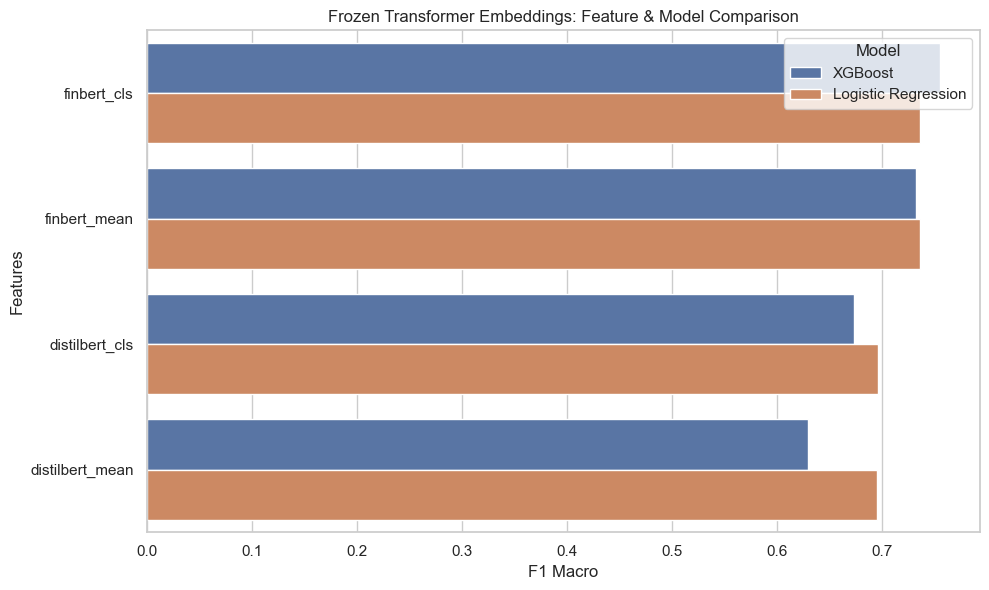

In [50]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_results, x="F1 Macro", y="Features", hue="Model")
plt.title("Frozen Transformer Embeddings: Feature & Model Comparison")
plt.tight_layout()
plt.show()

### 7.3 Consolidated Comparison

This is the final consolidated comparison. We pull every single run logged throughout the project into one master table, filtering down to the single best run for each model/feature combination to identify our best-performing model.

#### Loading the Full History

In [51]:
df = pd.read_csv("outputs/results.csv")

print(df.shape)
df.head()

(54, 11)


,timestamp,owner,model_name,feature_description,accuracy,precision_macro,recall_macro,f1_macro,parameters,f1_per_class,notes
0,2026-06-13 15:22:45,NaN,Majority Class Baseline,NaN,0.6475,0.2158,0.3333,0.2620,majority_class=2 (Neutral),"{'Bearish': 0.0, 'Bullish': 0.0, 'Neutral': 0....",NaN
1,2026-05-25 09:34:24,NaN,Logistic Regression Baseline,"TF-IDF (1,1)",0.7685,0.6910,0.7015,0.6955,"ngram_range=(1, 1), min_df=1, max_features=None","{'Bearish': 0.5751633986928104, 'Bullish': 0.6...",NaN
2,2026-05-25 09:34:25,NaN,Logistic Regression Baseline,"TF-IDF (1,2)",0.7800,0.7019,0.7057,0.7038,"ngram_range=(1, 2), min_df=1, max_features=None","{'Bearish': 0.5862068965517241, 'Bullish': 0.6...",NaN
3,2026-05-25 09:34:26,NaN,Logistic Regression Baseline,"TF-IDF (1,2) Optimized",0.7795,0.7021,0.7175,0.7091,"ngram_range=(1, 2), min_df=2, max_features=25000","{'Bearish': 0.5980392156862745, 'Bullish': 0.6...",NaN
4,2026-05-25 09:34:27,NaN,KNN Baseline,"TF-IDF (1,2) Optimized",0.6888,0.7305,0.4212,0.4247,n_neighbors=3,"{'Bearish': 0.21114369501466276, 'Bullish': 0....",NaN


#### Normalising Names

We clean up the names so identical models run under slightly different strings are grouped properly.

In [52]:
df["model_name"] = (
    df["model_name"]
    .replace({
        "Logistic Regression Baseline": "Logistic Regression",
        "KNN Baseline": "KNN",
        "Multinomial NB Baseline": "Multinomial NB",
        "Random Forest Baseline": "Random Forest",
        "XGBoost Baseline": "XGBoost",
        "MLP Classifier": "MLP",
    })
)

#### Filtering for the Best Runs

In [53]:
best_results = (
    df.sort_values("f1_macro", ascending=False)
      .drop_duplicates(
          subset=["model_name", "feature_description"],
          keep="first"
      )
)

best_results

,timestamp,owner,model_name,feature_description,accuracy,precision_macro,recall_macro,f1_macro,parameters,f1_per_class,notes
50,2026-06-15 16:38:05,NaN,Twitter-RoBERTa,HF fine-tune,0.8779,0.8371,0.8546,0.8453,model=cardiffnlp/twitter-roberta-base-sentimen...,"{'Bearish': 0.7840531561461794, 'Bullish': 0.8...",tm_final champion (full data)
19,2026-05-25 10:48:06,La Feria,DistilBERT,HF fine-tune,0.8628,0.8361,0.7964,0.8143,"model=distilbert-base-uncased, max_length=128","{'Bearish': 0.7340823970037453, 'Bullish': 0.8...","TM-024 final DistilBERT, full data, lr=2e-5, b..."
29,2026-06-15 16:47:15,NaN,Logistic Regression,"TF-IDF (1,2) opt",0.7926,0.7193,0.7208,0.7200,"class_weight=balanced, C=4.0","{'Bearish': 0.603448275862069, 'Bullish': 0.68...",NaN
31,2026-06-15 16:47:16,NaN,LinearSVC,"TF-IDF (1,2) opt",0.7994,0.7422,0.6919,0.7132,C=0.3,"{'Bearish': 0.5877862595419847, 'Bullish': 0.6...",NaN
48,2026-06-13 15:52:45,Pedro,Logistic Regression,"TF-IDF (1,2) Optimized",0.7810,0.7041,0.7201,0.7113,best_imbalance_strategy=class_weight,"{'Bearish': 0.5970636215334421, 'Bullish': 0.6...",NaN
12,2026-05-25 09:35:36,NaN,MLP,"TF-IDF (1,2) Optimized",0.8025,0.7590,0.6728,0.7051,"hidden_layer_sizes=(100, 50), learning_rate_in...","{'Bearish': 0.5585215605749486, 'Bullish': 0.6...",NaN
2,2026-05-25 09:34:25,NaN,Logistic Regression,"TF-IDF (1,2)",0.7800,0.7019,0.7057,0.7038,"ngram_range=(1, 2), min_df=1, max_features=None","{'Bearish': 0.5862068965517241, 'Bullish': 0.6...",NaN
1,2026-05-25 09:34:24,NaN,Logistic Regression,"TF-IDF (1,1)",0.7685,0.6910,0.7015,0.6955,"ngram_range=(1, 1), min_df=1, max_features=None","{'Bearish': 0.5751633986928104, 'Bullish': 0.6...",NaN
10,2026-05-25 09:34:37,NaN,Multinomial NB,"TF-IDF (1,2) Optimized",0.7863,0.7527,0.6415,0.6791,alpha=0.1,"{'Bearish': 0.5411255411255411, 'Bullish': 0.6...",NaN
39,2026-06-15 11:15:23,NaN,FinBERT,HF fine-tune,0.7625,0.6694,0.6681,0.6664,"model=ProsusAI/finbert, max_length=128","{'Bearish': 0.5384615384615384, 'Bullish': 0.5...",EXTRA WORK: FinBERT fine-tune


In [54]:
best_results.to_csv(
    "outputs/results_best.csv",
    index=False
)

#### Final Leaderboard

The final sorted table clearly shows Twitter-RoBERTa as our champion, which is why it gets its own dedicated notebook (`tm_final_31.ipynb`) for the final test set prediction.

In [55]:
report_table = best_results[
    [
        "model_name",
        "feature_description",
        "f1_macro"
    ]
].copy()

report_table = report_table.rename(columns={
    "model_name": "Model",
    "feature_description": "Feature",
    "f1_macro": "Macro_F1"
})

report_table = report_table.sort_values(
    "Macro_F1",
    ascending=False
)

report_table["Macro_F1"] = report_table["Macro_F1"].round(4)

report_table

,Model,Feature,Macro_F1
50,Twitter-RoBERTa,HF fine-tune,0.8453
19,DistilBERT,HF fine-tune,0.8143
29,Logistic Regression,"TF-IDF (1,2) opt",0.7200
31,LinearSVC,"TF-IDF (1,2) opt",0.7132
48,Logistic Regression,"TF-IDF (1,2) Optimized",0.7113
12,MLP,"TF-IDF (1,2) Optimized",0.7051
2,Logistic Regression,"TF-IDF (1,2)",0.7038
1,Logistic Regression,"TF-IDF (1,1)",0.6955
10,Multinomial NB,"TF-IDF (1,2) Optimized",0.6791
39,FinBERT,HF fine-tune,0.6664


In [56]:
report_table.to_csv(
    "outputs/report_BestResultsTable.csv",
    index=False
)

#### Visualizing the Champion

A final bar chart ranking all our best configurations by Macro F1.

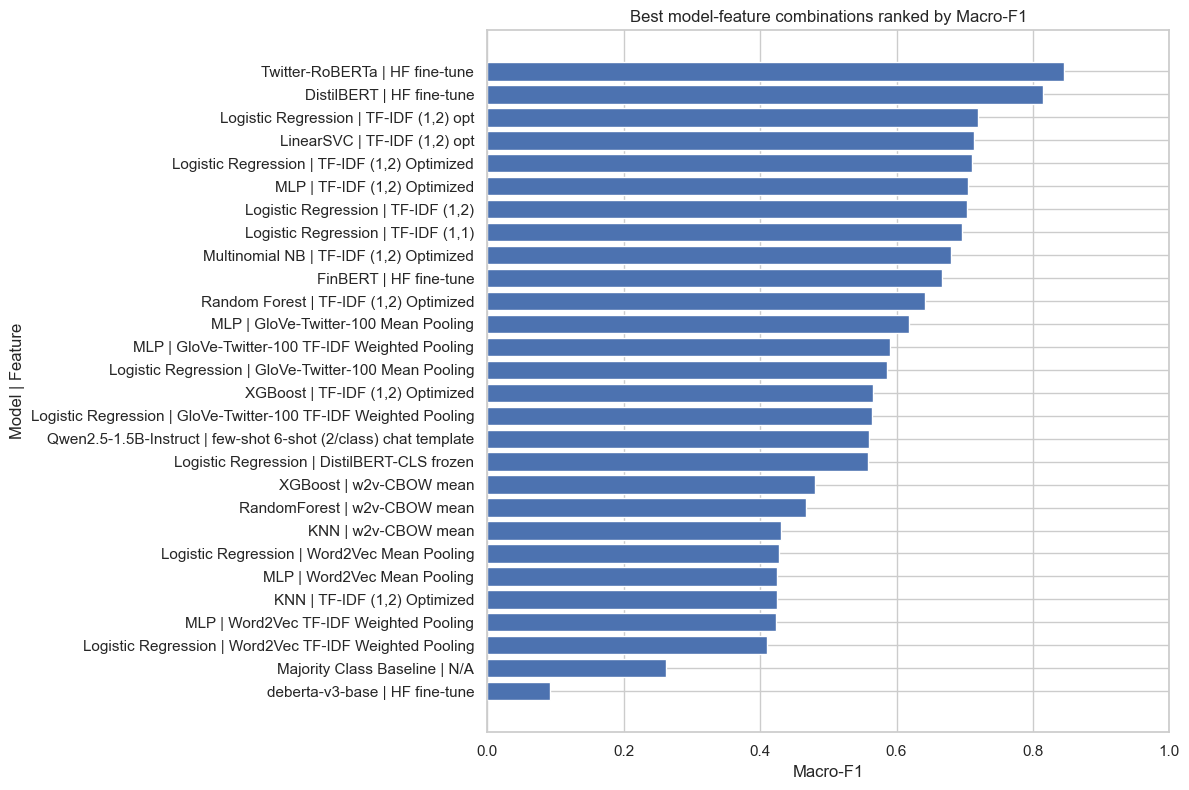

In [57]:
plot_df = report_table.copy()

plot_df["Model"] = plot_df["Model"].fillna("Unknown").astype(str)
plot_df["Feature"] = plot_df["Feature"].fillna("N/A").astype(str)
plot_df["Macro_F1"] = plot_df["Macro_F1"].astype(float)

plot_df["Model_Feature"] = (
    plot_df["Model"] + " | " + plot_df["Feature"]
)

plot_df = plot_df.sort_values("Macro_F1", ascending=True)

plt.figure(figsize=(12, 8))

plt.barh(
    plot_df["Model_Feature"],
    plot_df["Macro_F1"]
)

plt.xlabel("Macro-F1")
plt.ylabel("Model | Feature")
plt.title("Best model-feature combinations ranked by Macro-F1")
plt.xlim(0, 1)

plt.tight_layout()

plt.savefig(
    "outputs/report_bar_chart_macro_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()